In [ ]:
from google.colab import drive
from pathlib import Path
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# Hybrid AI Image Attributor
# - DINOv2 + OpenCLIP + Artifact features
# - Train / Val / Test split
# - Extended evaluation metrics & visualization
# - Colab-ready
# ============================================================

# -----------------------------
# 0) Install Requirements
# -----------------------------
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install scikit-image opencv-python-headless open_clip_torch xgboost joblib tqdm seaborn openpyxl matplotlib
# -----------------------------
# 1) Imports
# -----------------------------
import os
import cv2
import json
import math
import joblib
import random
import shutil
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from functools import lru_cache

import torch
import torch.nn.functional as F
from torchvision import transforms

import open_clip

from scipy import stats
from scipy.fft import fft2, fftshift

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    top_k_accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef
)
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
import xgboost as xgb_module  # avoid name collision with XGBClassifier instances
from joblib import Parallel, delayed

from skimage.feature import graycomatrix, graycoprops, canny
from skimage.filters import sobel_h, sobel_v, laplace

import matplotlib.pyplot as plt
import seaborn as sns

import tempfile

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True, warn_only=True)

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


In [ ]:
# Dataset and output paths (single source of truth)
EXTRACT_DIR = "/content/drive/MyDrive/window_AIDetector/finalDataset"
ARTIFACT_SAVE = os.path.join(EXTRACT_DIR, "hybrid_attributor_artifacts.pkl")
RAW_FEATURES_PATH = os.path.join(EXTRACT_DIR, "raw_features.pkl")
ADDITIONAL_RESULT_DIR = "/content/drive/MyDrive/Window_AIGIAttributor&novelty"

IMG_SIZE_ARTIFACT = 256
IMG_SIZE_DINO = 224
IMG_SIZE_CLIP = 224

BATCH_SIZE = 16
UNKNOWN_THRESHOLD = 0.45

TEST_SIZE = 0.15
VAL_SIZE_FROM_REMAIN = 0.1765  # ~15% val overall (train 70 / val 15 / test 15)

In [ ]:
# -----------------------------
# 4) Basic utils
# -----------------------------
def list_image_files(root_dir, exts=(".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tiff")):
    items, labels = [], []
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        count = 0
        for sub_root, _, files in os.walk(class_dir):
            for fname in files:
                if fname.lower().endswith(exts):
                    items.append(os.path.join(sub_root, fname))
                    labels.append(class_name)
                    count += 1
        print(f"[INFO] {class_name}: {count} images")
    return items, labels

def pil_rgb(path):
    return Image.open(path).convert("RGB")

def np_rgb(path, size=256):
    img = pil_rgb(path).resize((size, size))
    return np.array(img)

def safe_stat(x, fn, default=0.0):
    try:
        return float(fn(x))
    except Exception:
        return float(default)

# -----------------------------
# 5) Artifact feature extractor
# -----------------------------
def channel_stats(ch):
    ch = ch.flatten().astype(np.float32)
    return {
        "mean": float(np.mean(ch)),
        "std": float(np.std(ch)),
        "min": float(np.min(ch)),
        "max": float(np.max(ch)),
        "median": float(np.median(ch)),
        "p10": float(np.percentile(ch, 10)),
        "p90": float(np.percentile(ch, 90)),
        "skew": safe_stat(ch, stats.skew),
        "kurtosis": safe_stat(ch, stats.kurtosis),
    }

def histogram_features(ch, bins=16, prefix="hist"):
    hist, _ = np.histogram(ch.flatten(), bins=bins, range=(0, 255), density=True)
    return {f"{prefix}_{i}": float(v) for i, v in enumerate(hist)}

def radial_profile(data):
    y, x = np.indices(data.shape)
    center = np.array([(data.shape[0] - 1) / 2.0, (data.shape[1] - 1) / 2.0])
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(np.int32)
    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    rp = tbin / np.maximum(nr, 1)
    return rp

def fft_features(gray):
    g = gray.astype(np.float32)
    Freq = fftshift(fft2(g))
    mag = np.log1p(np.abs(Freq))

    h, w = mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    max_r = np.max(dist)

    low_mask = dist <= 0.10 * max_r
    mid_mask = (dist > 0.10 * max_r) & (dist <= 0.35 * max_r)
    high_mask = dist > 0.35 * max_r

    total = np.sum(mag) + 1e-8
    low_e = np.sum(mag[low_mask]) / total
    mid_e = np.sum(mag[mid_mask]) / total
    high_e = np.sum(mag[high_mask]) / total

    rp = radial_profile(mag)
    rp = rp[:64] if len(rp) >= 64 else np.pad(rp, (0, 64 - len(rp)))

    feats = {
        "fft_low_energy_ratio": float(low_e),
        "fft_mid_energy_ratio": float(mid_e),
        "fft_high_energy_ratio": float(high_e),
        "fft_high_low_ratio": float(high_e / (low_e + 1e-8)),
        "fft_mean": float(np.mean(mag)),
        "fft_std": float(np.std(mag)),
    }
    for i in range(16):
        feats[f"fft_radial_bin_{i}"] = float(np.mean(rp[i*4:(i+1)*4]))
    return feats

def edge_features(gray):
    g = gray.astype(np.float32) / 255.0
    sh = sobel_h(g)
    sv = sobel_v(g)
    sm = np.sqrt(sh**2 + sv**2)

    lap = laplace(g)
    can = canny(g, sigma=1.2).astype(np.float32)
    angle = np.arctan2(sv + 1e-8, sh + 1e-8)

    return {
        "sobel_mean": float(np.mean(sm)),
        "sobel_std": float(np.std(sm)),
        "sobel_p90": float(np.percentile(sm, 90)),
        "laplace_abs_mean": float(np.mean(np.abs(lap))),
        "laplace_var": float(np.var(lap)),
        "canny_edge_density": float(np.mean(can)),
        "edge_angle_mean": float(np.mean(angle)),
        "edge_angle_std": float(np.std(angle)),
    }

def glcm_features(gray):
    g = gray.astype(np.uint8)
    g_small = (g / 32).astype(np.uint8)
    glcm = graycomatrix(
        g_small,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=8,
        symmetric=True,
        normed=True
    )
    feats = {}
    props = ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation"]
    for p in props:
        vals = graycoprops(glcm, p)
        feats[f"glcm_{p}_mean"] = float(np.mean(vals))
        feats[f"glcm_{p}_std"] = float(np.std(vals))
    return feats

def block_artifact_features(gray, block_size=8):
    g = gray.astype(np.float32)
    dv = np.abs(np.diff(g, axis=1))
    dh = np.abs(np.diff(g, axis=0))

    v_idx = [i - 1 for i in range(block_size, g.shape[1], block_size) if i - 1 < dv.shape[1]]
    h_idx = [i - 1 for i in range(block_size, g.shape[0], block_size) if i - 1 < dh.shape[0]]

    if len(v_idx) > 0:
        dv_b = dv[:, v_idx]
        mask = np.ones(dv.shape[1], dtype=bool)
        mask[v_idx] = False
        dv_n = dv[:, mask]
        v_ratio = float(np.mean(dv_b) / (np.mean(dv_n) + 1e-8))
    else:
        v_ratio = 1.0

    if len(h_idx) > 0:
        dh_b = dh[h_idx, :]
        mask = np.ones(dh.shape[0], dtype=bool)
        mask[h_idx] = False
        dh_n = dh[mask, :]
        h_ratio = float(np.mean(dh_b) / (np.mean(dh_n) + 1e-8))
    else:
        h_ratio = 1.0

    return {
        "blockiness_vertical_ratio": v_ratio,
        "blockiness_horizontal_ratio": h_ratio,
        "blockiness_mean_ratio": float((v_ratio + h_ratio) / 2.0),
    }

def noise_residual_features(rgb):
    rgbf = rgb.astype(np.float32)
    blur = cv2.GaussianBlur(rgbf, (3, 3), 0)
    residual = rgbf - blur

    feats = {
        "residual_mean": float(np.mean(residual)),
        "residual_std": float(np.std(residual)),
        "residual_abs_mean": float(np.mean(np.abs(residual))),
        "residual_p90": float(np.percentile(np.abs(residual), 90)),
    }

    for c, name in enumerate(["r", "g", "b"]):
        rc = residual[:, :, c]
        feats[f"residual_{name}_std"] = float(np.std(rc))
        feats[f"residual_{name}_abs_mean"] = float(np.mean(np.abs(rc)))
    return feats

def rgb_relation_features(rgb):
    r = rgb[:, :, 0].astype(np.float32)
    g = rgb[:, :, 1].astype(np.float32)
    b = rgb[:, :, 2].astype(np.float32)

    feats = {}
    for ch, name in zip([r, g, b], ["r", "g", "b"]):
        st = channel_stats(ch)
        for k, v in st.items():
            feats[f"{name}_{k}"] = v
        feats.update(histogram_features(ch, bins=16, prefix=f"{name}_hist"))

    rg, rb, gb = r - g, r - b, g - b
    for diff, name in zip([rg, rb, gb], ["rg", "rb", "gb"]):
        feats[f"{name}_mean"] = float(np.mean(diff))
        feats[f"{name}_std"] = float(np.std(diff))
        feats[f"{name}_abs_mean"] = float(np.mean(np.abs(diff)))

    def safe_corr(a, b):
        try:
            c = np.corrcoef(a.flatten(), b.flatten())[0, 1]
            if np.isnan(c):
                return 0.0
            return float(c)
        except Exception:
            return 0.0

    feats["corr_rg"] = safe_corr(r, g)
    feats["corr_rb"] = safe_corr(r, b)
    feats["corr_gb"] = safe_corr(g, b)

    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    feats["h_mean"] = float(np.mean(hsv[:, :, 0]))
    feats["s_mean"] = float(np.mean(hsv[:, :, 1]))
    feats["v_mean"] = float(np.mean(hsv[:, :, 2]))
    feats["s_std"] = float(np.std(hsv[:, :, 1]))
    feats["v_std"] = float(np.std(hsv[:, :, 2]))
    return feats

def extract_artifact_features(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    feats = {}
    feats.update(rgb_relation_features(rgb))
    feats.update(fft_features(gray))
    feats.update(edge_features(gray))
    feats.update(glcm_features(gray))
    feats.update(block_artifact_features(gray))
    feats.update(noise_residual_features(rgb))
    return feats

# -----------------------------
# 6) Embedding Extractors Initialization
# -----------------------------
dino_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_DINO, IMG_SIZE_DINO)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

print("[INFO] Loading DINOv2...")
dino_model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")
dino_model.eval().to(DEVICE)

print("[INFO] Loading OpenCLIP...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-H-14", pretrained="laion2b_s32b_b79k", device=DEVICE
)
clip_model.eval()

def batchify(lst, bs):
    for i in range(0, len(lst), bs):
        yield lst[i:i+bs]

@torch.no_grad()
def extract_embeddings_unified(paths, batch_size=16, tta=True):
    dino_all, clip_all = [], []
    for batch_paths in tqdm(list(batchify(paths, batch_size)), desc="Extracting DINO & CLIP"):
        d_imgs, c_imgs = [], []
        d_imgs_f, c_imgs_f = [], []

        for p in batch_paths:
            img = pil_rgb(p)
            d_imgs.append(dino_transform(img))
            c_imgs.append(clip_preprocess(img))

            if tta:
                img_f = img.transpose(Image.FLIP_LEFT_RIGHT)
                d_imgs_f.append(dino_transform(img_f))
                c_imgs_f.append(clip_preprocess(img_f))

        dx = torch.stack(d_imgs).to(DEVICE)
        d_emb = F.normalize(dino_model(dx), dim=-1)
        if tta:
            dxf = torch.stack(d_imgs_f).to(DEVICE)
            d_emb_f = F.normalize(dino_model(dxf), dim=-1)
            d_emb = F.normalize((d_emb + d_emb_f) / 2.0, dim=-1)
        dino_all.append(d_emb.cpu().numpy())

        cx = torch.stack(c_imgs).to(DEVICE)
        c_emb = F.normalize(clip_model.encode_image(cx), dim=-1)
        if tta:
            cxf = torch.stack(c_imgs_f).to(DEVICE)
            c_emb_f = F.normalize(clip_model.encode_image(cxf), dim=-1)
            c_emb = F.normalize((c_emb + c_emb_f) / 2.0, dim=-1)
        clip_all.append(c_emb.cpu().numpy())

    return np.concatenate(dino_all, axis=0), np.concatenate(clip_all, axis=0)

# -----------------------------
# 7) Prepare dataset
# -----------------------------

image_paths, labels = list_image_files(EXTRACT_DIR)
assert len(image_paths) > 0, "No images found in dataset directory."

print("[INFO] Extracting artifact features (Parallel Processing)...")

def process_single_artifact(p):
    try:
        rgb = np_rgb(p, IMG_SIZE_ARTIFACT)
        return extract_artifact_features(rgb)
    except Exception:
        return None

results = Parallel(n_jobs=4)(
    delayed(process_single_artifact)(p) for p in tqdm(image_paths, desc="Artifacts")
)

artifact_rows = []
valid_paths, valid_labels = [], []

for p, label, feats in zip(image_paths, labels, results):
    if feats is not None:
        artifact_rows.append(feats)
        valid_paths.append(p)
        valid_labels.append(label)

image_paths = valid_paths
labels = valid_labels

artifact_df = pd.DataFrame(artifact_rows)
artifact_df = artifact_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

artifact_feature_names = artifact_df.columns.tolist()
X_art = artifact_df.values.astype(np.float32)
print("[INFO] Artifact shape:", X_art.shape)

X_dino, X_clip = extract_embeddings_unified(image_paths, batch_size=BATCH_SIZE, tta=True)
print("[INFO] DINO shape:", X_dino.shape)
print("[INFO] OpenCLIP shape:", X_clip.shape)

le = LabelEncoder()
y = le.fit_transform(labels)

[INFO] Loading DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:02<00:00, 130MB/s]


[INFO] Loading OpenCLIP...


open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

[INFO] biggan: 2500 images
[INFO] dalle3: 2500 images
[INFO] firefly: 2058 images
[INFO] midjourney: 2500 images
[INFO] progan: 2500 images
[INFO] sd2.0: 2500 images
[INFO] stylegan3: 1999 images
[INFO] Extracting artifact features (Parallel Processing)...


Artifacts: 100%|██████████| 16557/16557 [37:34<00:00,  7.34it/s]


[INFO] Artifact shape: (16557, 147)


Extracting DINO & CLIP: 100%|██████████| 1035/1035 [1:28:19<00:00,  5.12s/it]

[INFO] DINO shape: (16557, 768)
[INFO] OpenCLIP shape: (16557, 1024)


In [ ]:
# Save raw features for reuse
joblib.dump({
    "X_art": X_art,                # (N, artifact_dim) raw, before scaling
    "X_dino": X_dino,              # (N, 768) raw, before scaling/PCA
    "X_clip": X_clip,              # (N, 1024) raw, before scaling/PCA
    "labels": labels,              # list of str, length N
    "image_paths": image_paths,
    "artifact_feature_names": artifact_feature_names,
}, RAW_FEATURES_PATH)

print(f"[SAVED] {RAW_FEATURES_PATH}")

[SAVED] /content/drive/MyDrive/window_AIDetector/finalDataset/raw_features.pkl


[INFO] Train: 11589 | Val: 2484 | Test: 2484
[INFO] Final train shape: (11589, 659)
[INFO] Final val shape: (2484, 659)
[INFO] Final test shape: (2484, 659)
[INFO] Training LogisticRegression...
[INFO] Training XGBoost (with Early Stopping)...
[0]	validation_0-mlogloss:1.85577
[100]	validation_0-mlogloss:0.20921
[200]	validation_0-mlogloss:0.10257
[300]	validation_0-mlogloss:0.08440
[400]	validation_0-mlogloss:0.07871
[500]	validation_0-mlogloss:0.07575
[600]	validation_0-mlogloss:0.07400
[700]	validation_0-mlogloss:0.07286
[800]	validation_0-mlogloss:0.07202
[900]	validation_0-mlogloss:0.07135
[999]	validation_0-mlogloss:0.07070

[VAL] Metrics
Accuracy           : 0.9867
Balanced Accuracy  : 0.9874
Macro Precision    : 0.9869
Macro Recall       : 0.9874
Macro F1           : 0.9872
Weighted F1        : 0.9867
MCC                : 0.9845
Top-2 Accuracy     : 0.9980
Top-3 Accuracy     : 1.0000
ROC-AUC (macro OVR): 0.9996

[Classification Report]
              precision    recall  f1-scor

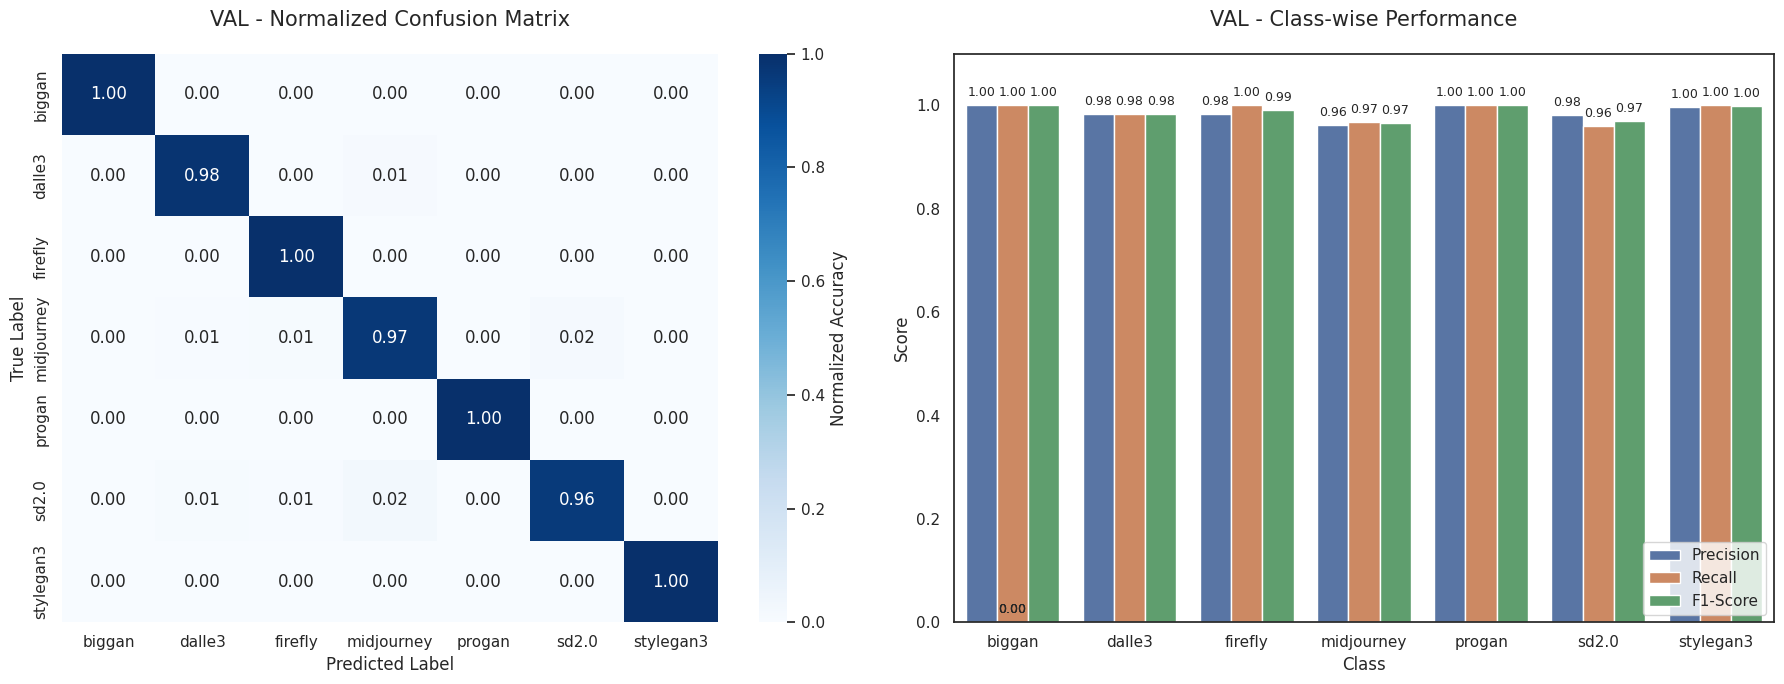

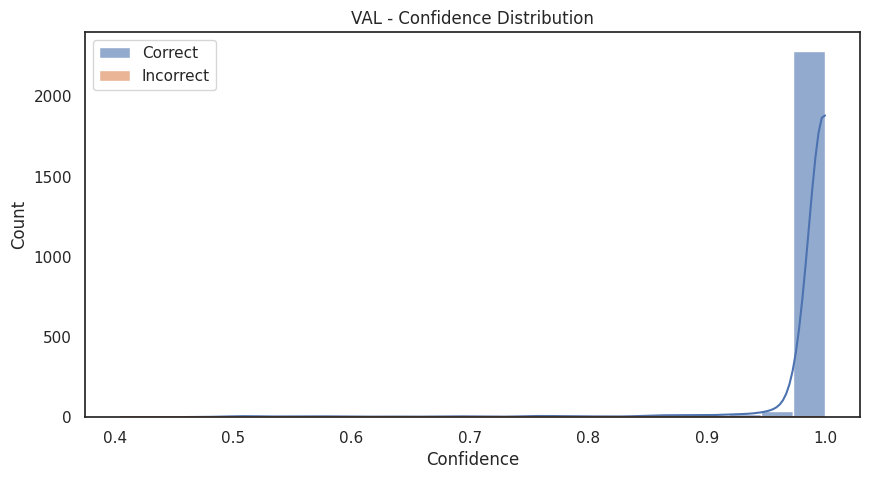


[TEST] Metrics
Accuracy           : 0.9859
Balanced Accuracy  : 0.9867
Macro Precision    : 0.9864
Macro Recall       : 0.9867
Macro F1           : 0.9865
Weighted F1        : 0.9859
MCC                : 0.9835
Top-2 Accuracy     : 0.9988
Top-3 Accuracy     : 0.9996
ROC-AUC (macro OVR): 0.9996

[Classification Report]
              precision    recall  f1-score   support

      biggan       1.00      1.00      1.00       375
      dalle3       0.98      0.99      0.98       375
     firefly       0.99      1.00      1.00       309
  midjourney       0.96      0.97      0.96       375
      progan       1.00      1.00      1.00       375
       sd2.0       0.98      0.96      0.97       375
   stylegan3       1.00      1.00      1.00       300

    accuracy                           0.99      2484
   macro avg       0.99      0.99      0.99      2484
weighted avg       0.99      0.99      0.99      2484

[TEST] Unknown threshold = 0.45
Known-only accuracy : 0.9859
Unknown prediction ra

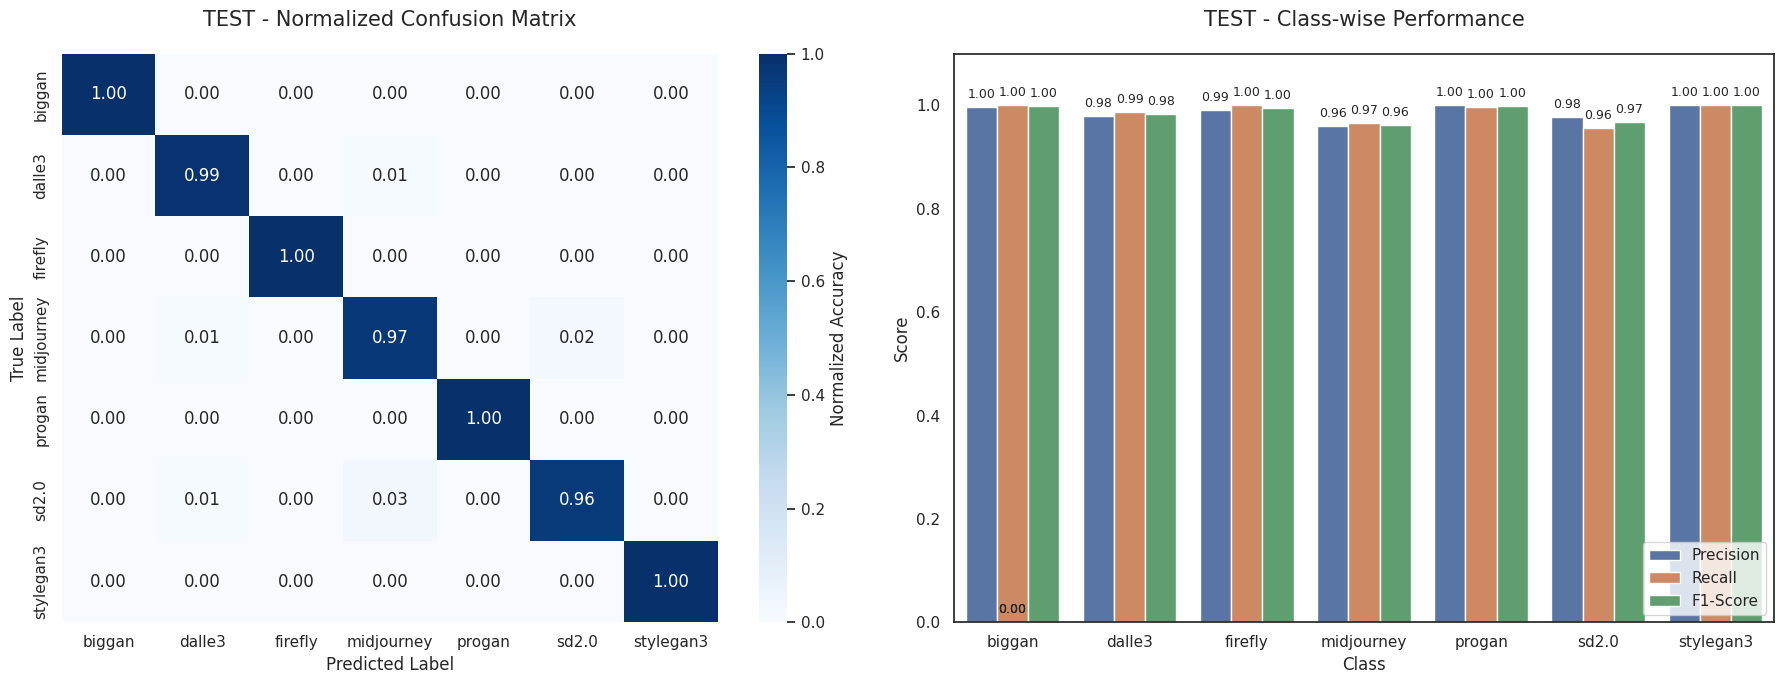

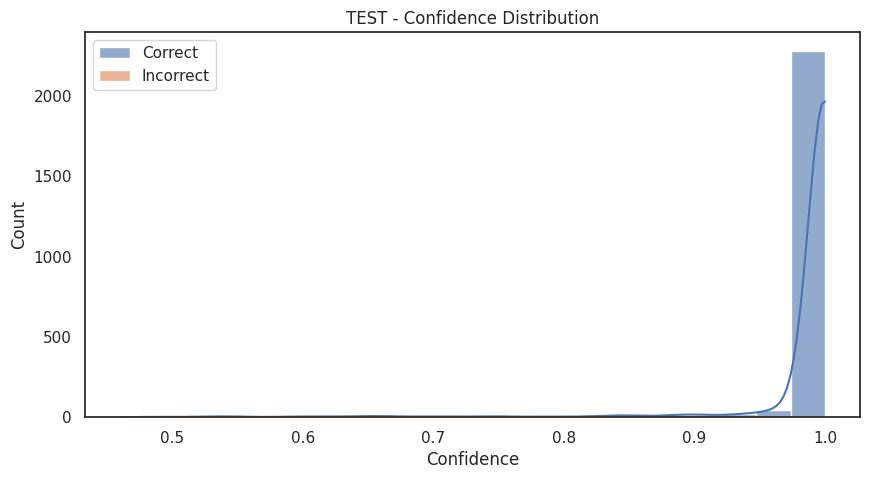

[INFO] Visualizing feature importances...


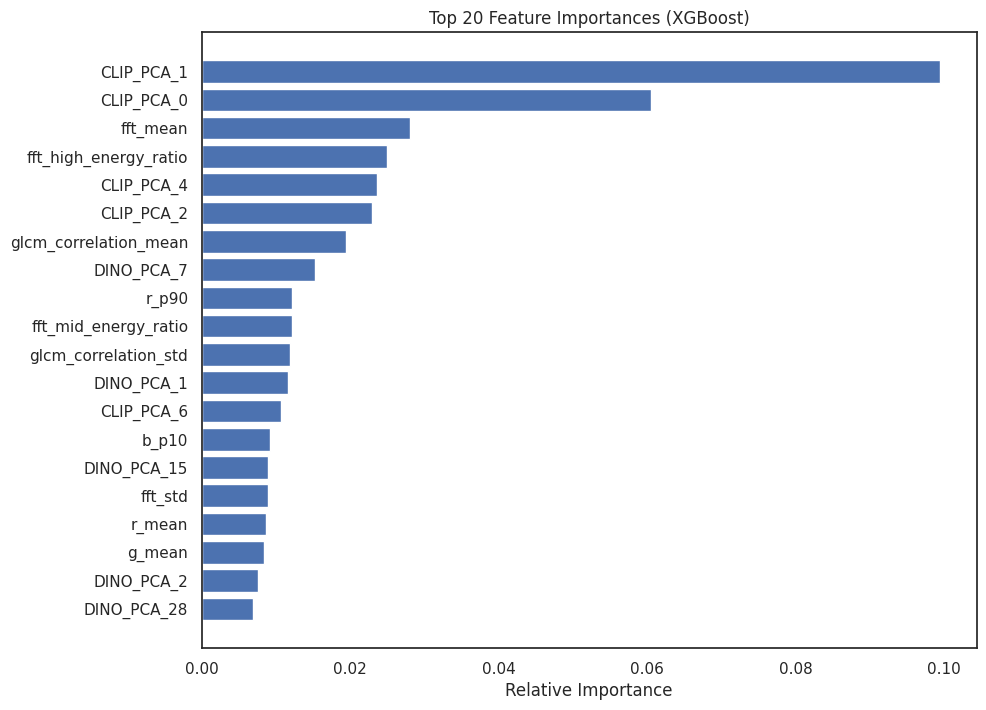

[SAVED] /content/drive/MyDrive/window_AIDetector/finalDataset/hybrid_attributor_artifacts.pkl

[SINGLE IMAGE TEST RESULT]
{
  "image_path": "/content/drive/MyDrive/window_AIDetector/finalDataset/biggan/img005959.jpg",
  "predicted_label": "biggan",
  "raw_top_label": "biggan",
  "confidence": 0.9999459981918335,
  "probabilities": {
    "biggan": 0.9999459981918335,
    "midjourney": 1.3876282537239604e-05,
    "progan": 1.1741018170141615e-05,
    "firefly": 1.1034046110580675e-05,
    "sd2.0": 1.0388977898401208e-05,
    "dalle3": 4.681606696976814e-06,
    "stylegan3": 2.3058826172928093e-06
  }
}


In [ ]:

# -----------------------------
# 8) Train / Val / Test split
# -----------------------------
indices = np.arange(len(y))

trainval_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

y_trainval = y[trainval_idx]

train_idx_rel, val_idx_rel = train_test_split(
    np.arange(len(trainval_idx)),
    test_size=VAL_SIZE_FROM_REMAIN,
    random_state=SEED,
    stratify=y_trainval
)

train_idx = trainval_idx[train_idx_rel]
val_idx = trainval_idx[val_idx_rel]

X_art_train, X_art_val, X_art_test = X_art[train_idx], X_art[val_idx], X_art[test_idx]
X_dino_train, X_dino_val, X_dino_test = X_dino[train_idx], X_dino[val_idx], X_dino[test_idx]
X_clip_train, X_clip_val, X_clip_test = X_clip[train_idx], X_clip[val_idx], X_clip[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f"[INFO] Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# -----------------------------
# 9) Preprocess each branch
# -----------------------------
art_scaler = StandardScaler()
X_art_train_s = art_scaler.fit_transform(X_art_train)
X_art_val_s = art_scaler.transform(X_art_val)
X_art_test_s = art_scaler.transform(X_art_test)

dino_scaler = StandardScaler()
X_dino_train_s = dino_scaler.fit_transform(X_dino_train)
X_dino_val_s = dino_scaler.transform(X_dino_val)
X_dino_test_s = dino_scaler.transform(X_dino_test)

dino_pca_dim = min(256, X_dino_train_s.shape[0] - 1, X_dino_train_s.shape[1])
if dino_pca_dim < 256:
    print(f"[WARNING] DINO PCA reduced to {dino_pca_dim} dims due to limited training data.")

dino_pca = PCA(n_components=dino_pca_dim, random_state=SEED)
X_dino_train_p = dino_pca.fit_transform(X_dino_train_s)
X_dino_val_p = dino_pca.transform(X_dino_val_s)
X_dino_test_p = dino_pca.transform(X_dino_test_s)

clip_scaler = StandardScaler()
X_clip_train_s = clip_scaler.fit_transform(X_clip_train)
X_clip_val_s = clip_scaler.transform(X_clip_val)
X_clip_test_s = clip_scaler.transform(X_clip_test)

clip_pca_dim = min(256, X_clip_train_s.shape[0] - 1, X_clip_train_s.shape[1])
if clip_pca_dim < 256:
    print(f"[WARNING] CLIP PCA reduced to {clip_pca_dim} dims due to limited training data.")

clip_pca = PCA(n_components=clip_pca_dim, random_state=SEED)
X_clip_train_p = clip_pca.fit_transform(X_clip_train_s)
X_clip_val_p = clip_pca.transform(X_clip_val_s)
X_clip_test_p = clip_pca.transform(X_clip_test_s)

X_train_final = np.concatenate([X_art_train_s, X_dino_train_p, X_clip_train_p], axis=1)
X_val_final = np.concatenate([X_art_val_s, X_dino_val_p, X_clip_val_p], axis=1)
X_test_final = np.concatenate([X_art_test_s, X_dino_test_p, X_clip_test_p], axis=1)

print("[INFO] Final train shape:", X_train_final.shape)
print("[INFO] Final val shape:", X_val_final.shape)
print("[INFO] Final test shape:", X_test_final.shape)

# -----------------------------
# 10) Train ensemble heads
# -----------------------------
print("[INFO] Training LogisticRegression...")
clf_lr = LogisticRegression(
    max_iter=5000,
    C=2.0,
    class_weight="balanced",
    solver="saga",
    multi_class="multinomial",
    n_jobs=-1,
    random_state=SEED
)
clf_lr.fit(X_train_final, y_train)

print("[INFO] Training XGBoost (with Early Stopping)...")
num_classes = len(le.classes_)
clf_xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=num_classes,
    reg_lambda=2.0,
    random_state=SEED,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=50
)

clf_xgb.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    verbose=100
)

# -----------------------------
# 11) Evaluation Helpers
# -----------------------------
def get_ensemble_proba(X):
    proba_lr = clf_lr.predict_proba(X)
    proba_xgb = clf_xgb.predict_proba(X)
    proba_ens = 0.5 * proba_lr + 0.5 * proba_xgb
    return proba_ens

def evaluate_split(y_true, proba, label_encoder, split_name="VAL", unknown_threshold=0.45):
    class_names = list(label_encoder.classes_)
    y_pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    top2 = top_k_accuracy_score(y_true, proba, k=min(2, len(class_names)), labels=np.arange(len(class_names)))
    top3 = top_k_accuracy_score(y_true, proba, k=min(3, len(class_names)), labels=np.arange(len(class_names)))

    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    try:
        roc_auc_macro_ovr = roc_auc_score(y_true_bin, proba, average="macro", multi_class="ovr")
    except Exception:
        roc_auc_macro_ovr = None

    print("\n" + "=" * 70)
    print(f"[{split_name}] Metrics")
    print("=" * 70)
    print(f"Accuracy           : {acc:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Macro Precision    : {precision_macro:.4f}")
    print(f"Macro Recall       : {recall_macro:.4f}")
    print(f"Macro F1           : {f1_macro:.4f}")
    print(f"Weighted F1        : {f1_weighted:.4f}")
    print(f"MCC                : {mcc:.4f}")
    print(f"Top-2 Accuracy     : {top2:.4f}")
    print(f"Top-3 Accuracy     : {top3:.4f}")
    if roc_auc_macro_ovr is not None:
        print(f"ROC-AUC (macro OVR): {roc_auc_macro_ovr:.4f}")

    print("\n[Classification Report]")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Unknown threshold evaluation
    pred_with_unknown = []
    correct_known = 0
    known_count = 0

    for yi, pi, ci in zip(y_true, y_pred, conf):
        if ci < unknown_threshold:
            pred_with_unknown.append("unknown")
        else:
            pred_label = class_names[pi]
            pred_with_unknown.append(pred_label)
            known_count += 1
            if yi == pi:
                correct_known += 1

    known_acc = correct_known / max(known_count, 1)
    unknown_ratio = np.mean(np.array(pred_with_unknown) == "unknown")

    print(f"[{split_name}] Unknown threshold = {unknown_threshold}")
    print(f"Known-only accuracy : {known_acc:.4f}")
    print(f"Unknown prediction ratio : {unknown_ratio:.4f}")

    return {
        "y_pred": y_pred,
        "confidence": conf,
        "metrics": {
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "macro_precision": precision_macro,
            "macro_recall": recall_macro,
            "macro_f1": f1_macro,
            "weighted_f1": f1_weighted,
            "mcc": mcc,
            "top2_accuracy": top2,
            "top3_accuracy": top3,
            "roc_auc_macro_ovr": roc_auc_macro_ovr,
            "known_only_accuracy": known_acc,
            "unknown_ratio": unknown_ratio,
        }
    }

def plot_confusion_and_metrics(y_true, y_pred, labels, title_prefix="VAL"):
    sns.set_theme(style="white")
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax[0],
        cbar_kws={"label": "Normalized Accuracy"}
    )
    ax[0].set_title(f"{title_prefix} - Normalized Confusion Matrix", fontsize=15, pad=20)
    ax[0].set_xlabel("Predicted Label", fontsize=12)
    ax[0].set_ylabel("True Label", fontsize=12)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

    metrics_df = pd.DataFrame({
        "Class": labels,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }).melt(id_vars="Class", var_name="Metric", value_name="Score")

    sns.barplot(data=metrics_df, x="Class", y="Score", hue="Metric", ax=ax[1])
    ax[1].set_title(f"{title_prefix} - Class-wise Performance", fontsize=15, pad=20)
    ax[1].set_ylim(0, 1.1)
    ax[1].legend(loc="lower right")

    for p in ax[1].patches:
        height = p.get_height()
        if not np.isnan(height):
            ax[1].annotate(
                format(height, ".2f"),
                (p.get_x() + p.get_width() / 2., height),
                ha="center",
                va="center",
                xytext=(0, 9),
                textcoords="offset points",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

def plot_confidence_distribution(confidence, y_true, y_pred, title_prefix="VAL"):
    correct = (y_true == y_pred)

    plt.figure(figsize=(10, 5))
    sns.histplot(confidence[correct], bins=20, kde=True, label="Correct", alpha=0.6)
    sns.histplot(confidence[~correct], bins=20, kde=True, label="Incorrect", alpha=0.6)
    plt.title(f"{title_prefix} - Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

def plot_top_feature_importance(clf_xgb, artifact_feature_names, X_dino_train_p, X_clip_train_p, top_n=20):
    plt.figure(figsize=(10, 8))
    all_features = (
        artifact_feature_names
        + [f"DINO_PCA_{i}" for i in range(X_dino_train_p.shape[1])]
        + [f"CLIP_PCA_{i}" for i in range(X_clip_train_p.shape[1])]
    )

    importances = clf_xgb.feature_importances_
    indices_feat = np.argsort(importances)[-top_n:]

    plt.title(f"Top {top_n} Feature Importances (XGBoost)")
    plt.barh(range(len(indices_feat)), importances[indices_feat], align="center")
    plt.yticks(range(len(indices_feat)), [all_features[i] for i in indices_feat])
    plt.xlabel("Relative Importance")
    plt.show()

# -----------------------------
# 12) Validation evaluation
# -----------------------------
class_names = list(le.classes_)

proba_val = get_ensemble_proba(X_val_final)
val_result = evaluate_split(y_val, proba_val, le, split_name="VAL", unknown_threshold=UNKNOWN_THRESHOLD)

print("[INFO] Visualizing VAL metrics...")
plot_confusion_and_metrics(y_val, val_result["y_pred"], class_names, title_prefix="VAL")
plot_confidence_distribution(val_result["confidence"], y_val, val_result["y_pred"], title_prefix="VAL")

# -----------------------------
# 13) Test evaluation
# -----------------------------
proba_test = get_ensemble_proba(X_test_final)
test_result = evaluate_split(y_test, proba_test, le, split_name="TEST", unknown_threshold=UNKNOWN_THRESHOLD)

print("[INFO] Visualizing TEST metrics...")
plot_confusion_and_metrics(y_test, test_result["y_pred"], class_names, title_prefix="TEST")
plot_confidence_distribution(test_result["confidence"], y_test, test_result["y_pred"], title_prefix="TEST")

print("[INFO] Visualizing feature importances...")
plot_top_feature_importance(clf_xgb, artifact_feature_names, X_dino_train_p, X_clip_train_p, top_n=20)

# -----------------------------
# 14) Save everything
# -----------------------------
artifact_bundle = {
    "label_encoder": le,
    "artifact_feature_names": artifact_feature_names,
    "art_scaler": art_scaler,
    "dino_scaler": dino_scaler,
    "dino_pca": dino_pca,
    "clip_scaler": clip_scaler,
    "clip_pca": clip_pca,
    "clf_lr": clf_lr,
    "clf_xgb": clf_xgb,
    "img_size_artifact": IMG_SIZE_ARTIFACT,
    "unknown_threshold": UNKNOWN_THRESHOLD,
    "class_names": class_names,
}

joblib.dump(artifact_bundle, ARTIFACT_SAVE)
print(f"[SAVED] {ARTIFACT_SAVE}")

# -----------------------------
# 15) Inference helpers
# -----------------------------
@lru_cache(maxsize=1)
def load_bundle(bundle_path):
    return joblib.load(bundle_path)

@torch.no_grad()
def extract_single_embeddings(path, tta=True):
    img = pil_rgb(path)

    dx = dino_transform(img).unsqueeze(0).to(DEVICE)
    d_emb = F.normalize(dino_model(dx), dim=-1)

    cx = clip_preprocess(img).unsqueeze(0).to(DEVICE)
    c_emb = F.normalize(clip_model.encode_image(cx), dim=-1)

    if tta:
        img_f = img.transpose(Image.FLIP_LEFT_RIGHT)

        dxf = dino_transform(img_f).unsqueeze(0).to(DEVICE)
        d_emb_f = F.normalize(dino_model(dxf), dim=-1)
        d_emb = F.normalize((d_emb + d_emb_f) / 2.0, dim=-1)

        cxf = clip_preprocess(img_f).unsqueeze(0).to(DEVICE)
        c_emb_f = F.normalize(clip_model.encode_image(cxf), dim=-1)
        c_emb = F.normalize((c_emb + c_emb_f) / 2.0, dim=-1)

    return d_emb.cpu().numpy(), c_emb.cpu().numpy()

def build_single_feature_vector(image_path, bundle):
    rgb = np_rgb(image_path, bundle["img_size_artifact"])
    art = extract_artifact_features(rgb)

    art_df = pd.DataFrame([art])
    art_df = art_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for c in bundle["artifact_feature_names"]:
        if c not in art_df.columns:
            art_df[c] = 0.0

    art_vec = art_df[bundle["artifact_feature_names"]].values.astype(np.float32)

    dino_vec, clip_vec = extract_single_embeddings(image_path, tta=True)

    art_s = bundle["art_scaler"].transform(art_vec)
    dino_s = bundle["dino_scaler"].transform(dino_vec)
    dino_p = bundle["dino_pca"].transform(dino_s)

    clip_s = bundle["clip_scaler"].transform(clip_vec)
    clip_p = bundle["clip_pca"].transform(clip_s)

    return np.concatenate([art_s, dino_p, clip_p], axis=1)

def predict_image(image_path, bundle_path=ARTIFACT_SAVE):
    bundle = load_bundle(bundle_path)
    le = bundle["label_encoder"]

    x = build_single_feature_vector(image_path, bundle)

    proba_lr = bundle["clf_lr"].predict_proba(x)[0]
    proba_xgb = bundle["clf_xgb"].predict_proba(x)[0]
    proba = 0.5 * proba_lr + 0.5 * proba_xgb

    pred_idx = int(np.argmax(proba))
    pred_label = le.inverse_transform([pred_idx])[0]
    conf = float(proba[pred_idx])

    final_label = pred_label if conf >= bundle["unknown_threshold"] else "unknown"

    probs = {le.inverse_transform([i])[0]: float(proba[i]) for i in range(len(proba))}
    probs = dict(sorted(probs.items(), key=lambda kv: kv[1], reverse=True))

    return {
        "image_path": image_path,
        "predicted_label": final_label,
        "raw_top_label": pred_label,
        "confidence": conf,
        "probabilities": probs
    }

# -----------------------------
# 16) Single image test example
# -----------------------------
# Change test_image_path below to run
test_image_path = image_paths[0]  # example
result = predict_image(test_image_path, ARTIFACT_SAVE)

print("\n[SINGLE IMAGE TEST RESULT]")
print(json.dumps(result, indent=2, ensure_ascii=False))


In [ ]:
# ============================================================
# 17) Additional Experiments for Paper Novelty
# - Feature Ablation
# - Family-level Attribution
# - Confidence Threshold Sweep
# - Robustness under Post-processing
# ============================================================

# ------------------------------------------------------------
# 17-1) Utility: evaluation table
# ------------------------------------------------------------
def summarize_multiclass_result(y_true, proba, label_encoder, name="MODEL"):
    y_pred = np.argmax(proba, axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("\n" + "=" * 70)
    print(f"[{name}] Summary")
    print("=" * 70)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {weighted_f1:.4f}")

    return {
        "name": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred,
        "proba": proba
    }


################################################################################
# Feature Ablation Study
################################################################################

[ABLATION] Training Artifact only...

[Artifact only] Summary
Accuracy    : 0.9340
Macro F1    : 0.9342
Weighted F1 : 0.9328

[ABLATION] Training DINOv2 only...

[DINOv2 only] Summary
Accuracy    : 0.9275
Macro F1    : 0.9301
Weighted F1 : 0.9268

[ABLATION] Training OpenCLIP only...

[OpenCLIP only] Summary
Accuracy    : 0.9754
Macro F1    : 0.9763
Weighted F1 : 0.9754

[ABLATION] Training DINOv2 + OpenCLIP...

[DINOv2 + OpenCLIP] Summary
Accuracy    : 0.9799
Macro F1    : 0.9806
Weighted F1 : 0.9798

[Full Hybrid: Artifact + DINOv2 + OpenCLIP] Summary
Accuracy    : 0.9859
Macro F1    : 0.9865
Weighted F1 : 0.9859

[ABLATION TABLE]


,Setting,Accuracy,Macro F1,Weighted F1
0,Artifact only,0.933977,0.934182,0.932801
1,DINOv2 only,0.927536,0.930131,0.926804
2,OpenCLIP only,0.975443,0.976310,0.975356
3,DINOv2 + OpenCLIP,0.979871,0.980580,0.979791
4,Full Hybrid: Artifact + DINOv2 + OpenCLIP,0.985910,0.986523,0.985886


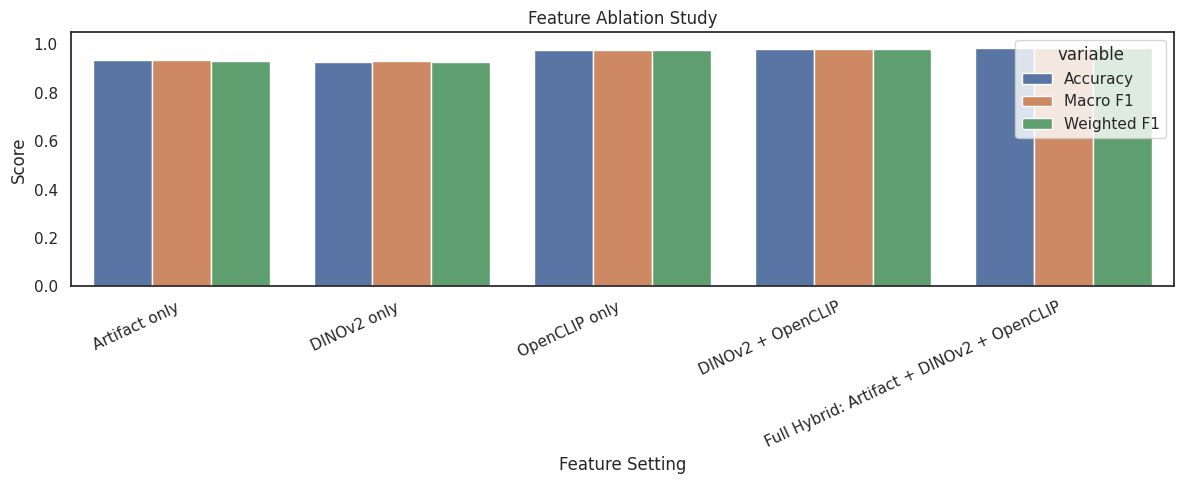

In [ ]:
# ============================================================
# 17-2) Feature Ablation Study
# ============================================================

def train_eval_simple_ensemble(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    name="Ablation"
):
    """
    Same idea as main model:
    Logistic Regression + XGBoost probability averaging.
    """
    print(f"\n[ABLATION] Training {name}...")

    lr = LogisticRegression(
        max_iter=3000,
        C=2.0,
        class_weight="balanced",
        solver="saga",
        multi_class="multinomial",
        n_jobs=-1,
        random_state=SEED
    )
    lr.fit(X_train, y_train)

    xgb_clf = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.04,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        num_class=len(le.classes_),
        reg_lambda=2.0,
        random_state=SEED,
        tree_method="hist",
        eval_metric="mlogloss",
        early_stopping_rounds=30
    )

    xgb_clf.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    proba = 0.5 * lr.predict_proba(X_test) + 0.5 * xgb_clf.predict_proba(X_test)
    result = summarize_multiclass_result(y_test, proba, le, name=name)

    return result, lr, xgb_clf


print("\n" + "#" * 80)
print("# Feature Ablation Study")
print("#" * 80)

ablation_results = []

# Artifact only
res_art, lr_art, xgb_clf_art = train_eval_simple_ensemble(
    X_art_train_s,
    X_art_val_s,
    X_art_test_s,
    y_train,
    y_val,
    y_test,
    name="Artifact only"
)
ablation_results.append(res_art)

# DINO only
res_dino, lr_dino, xgb_clf_dino = train_eval_simple_ensemble(
    X_dino_train_p,
    X_dino_val_p,
    X_dino_test_p,
    y_train,
    y_val,
    y_test,
    name="DINOv2 only"
)
ablation_results.append(res_dino)

# CLIP only
res_clip, lr_clip, xgb_clf_clip = train_eval_simple_ensemble(
    X_clip_train_p,
    X_clip_val_p,
    X_clip_test_p,
    y_train,
    y_val,
    y_test,
    name="OpenCLIP only"
)
ablation_results.append(res_clip)

# DINO + CLIP
X_train_dino_clip = np.concatenate([X_dino_train_p, X_clip_train_p], axis=1)
X_val_dino_clip = np.concatenate([X_dino_val_p, X_clip_val_p], axis=1)
X_test_dino_clip = np.concatenate([X_dino_test_p, X_clip_test_p], axis=1)

res_dino_clip, lr_dino_clip, xgb_clf_dino_clip = train_eval_simple_ensemble(
    X_train_dino_clip,
    X_val_dino_clip,
    X_test_dino_clip,
    y_train,
    y_val,
    y_test,
    name="DINOv2 + OpenCLIP"
)
ablation_results.append(res_dino_clip)

# Full hybrid result from already-trained model
res_full = summarize_multiclass_result(
    y_test,
    proba_test,
    le,
    name="Full Hybrid: Artifact + DINOv2 + OpenCLIP"
)
ablation_results.append(res_full)

ablation_df = pd.DataFrame([
    {
        "Setting": r["name"],
        "Accuracy": r["accuracy"],
        "Macro F1": r["macro_f1"],
        "Weighted F1": r["weighted_f1"]
    }
    for r in ablation_results
])

print("\n[ABLATION TABLE]")
display(ablation_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=ablation_df.melt(id_vars="Setting"), x="Setting", y="value", hue="variable")
plt.title("Feature Ablation Study")
plt.ylabel("Score")
plt.xlabel("Feature Setting")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


################################################################################
# Family-level Attribution
################################################################################
Family-level Accuracy : 0.9903
Family-level Macro F1 : 0.9855

[Family-level Classification Report]
                precision    recall  f1-score   support

Commercial_T2I       0.99      0.99      0.99      1059
     Diffusion       0.98      0.96      0.97       375
           GAN       1.00      1.00      1.00      1050

      accuracy                           0.99      2484
     macro avg       0.99      0.98      0.99      2484
  weighted avg       0.99      0.99      0.99      2484



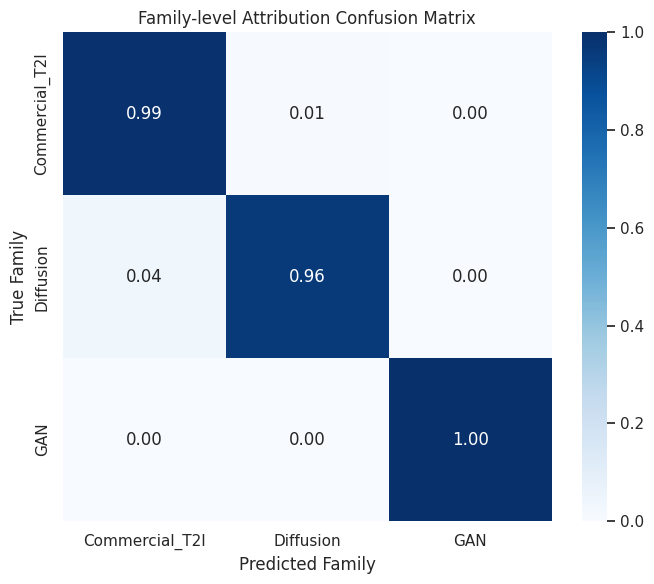

In [ ]:
# ============================================================
# 17-3) Family-level Attribution
# ============================================================

print("\n" + "#" * 80)
print("# Family-level Attribution")
print("#" * 80)

# Generator-to-family mapping
family_map = {
    "biggan": "GAN",
    "progan": "GAN",
    "stylegan3": "GAN",
    "sd2.0": "Diffusion",
    "dalle3": "Commercial_T2I",
    "midjourney": "Commercial_T2I",
    "firefly": "Commercial_T2I",
}

class_names = list(le.classes_)
class_to_family = {i: family_map[class_names[i]] for i in range(len(class_names))}

y_test_model_pred = np.argmax(proba_test, axis=1)

y_test_family_true = np.array([class_to_family[i] for i in y_test])
y_test_family_pred = np.array([class_to_family[i] for i in y_test_model_pred])

family_labels = sorted(list(set(y_test_family_true)))

family_acc = accuracy_score(y_test_family_true, y_test_family_pred)
family_macro_f1 = f1_score(y_test_family_true, y_test_family_pred, average="macro", zero_division=0)

print(f"Family-level Accuracy : {family_acc:.4f}")
print(f"Family-level Macro F1 : {family_macro_f1:.4f}")

print("\n[Family-level Classification Report]")
print(classification_report(y_test_family_true, y_test_family_pred, labels=family_labels, zero_division=0))

cm_family = confusion_matrix(y_test_family_true, y_test_family_pred, labels=family_labels)
cm_family_norm = cm_family.astype(float) / np.maximum(cm_family.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_family_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=family_labels,
    yticklabels=family_labels
)
plt.title("Family-level Attribution Confusion Matrix")
plt.xlabel("Predicted Family")
plt.ylabel("True Family")
plt.tight_layout()
plt.show()


################################################################################
# Confidence Threshold Sweep
################################################################################


,Threshold,Coverage,Unknown Ratio,Accepted Accuracy,Accepted Macro F1
0,0.10,1.000000,0.000000,0.985910,0.986523
1,0.15,1.000000,0.000000,0.985910,0.986523
2,0.20,1.000000,0.000000,0.985910,0.986523
3,0.25,1.000000,0.000000,0.985910,0.986523
4,0.30,1.000000,0.000000,0.985910,0.986523
5,0.35,1.000000,0.000000,0.985910,0.986523
6,0.40,1.000000,0.000000,0.985910,0.986523
7,0.45,1.000000,0.000000,0.985910,0.986523
8,0.50,0.996377,0.003623,0.988283,0.988767
9,0.55,0.991143,0.008857,0.989846,0.990187


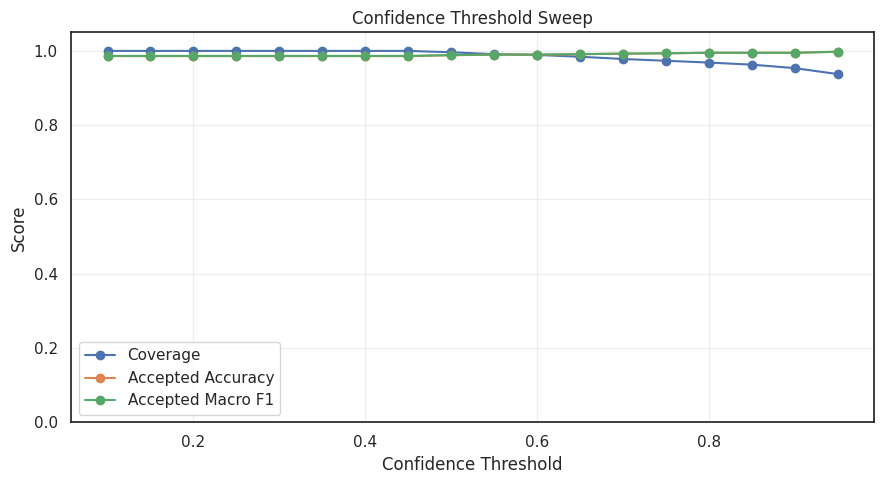

In [ ]:
# ============================================================
# 17-4) Confidence Threshold Sweep
# ============================================================

print("\n" + "#" * 80)
print("# Confidence Threshold Sweep")
print("#" * 80)

def confidence_threshold_sweep(y_true, proba, thresholds):
    y_pred = np.argmax(proba, axis=1)
    conf = np.max(proba, axis=1)

    rows = []
    for th in thresholds:
        accepted = conf >= th
        coverage = np.mean(accepted)

        if np.sum(accepted) > 0:
            accepted_acc = accuracy_score(y_true[accepted], y_pred[accepted])
            accepted_macro_f1 = f1_score(
                y_true[accepted],
                y_pred[accepted],
                average="macro",
                zero_division=0
            )
        else:
            accepted_acc = np.nan
            accepted_macro_f1 = np.nan

        unknown_ratio = 1.0 - coverage

        rows.append({
            "Threshold": th,
            "Coverage": coverage,
            "Unknown Ratio": unknown_ratio,
            "Accepted Accuracy": accepted_acc,
            "Accepted Macro F1": accepted_macro_f1
        })

    return pd.DataFrame(rows)

thresholds = np.round(np.arange(0.10, 0.96, 0.05), 2)
threshold_df = confidence_threshold_sweep(y_test, proba_test, thresholds)

display(threshold_df)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Coverage"], marker="o", label="Coverage")
plt.plot(threshold_df["Threshold"], threshold_df["Accepted Accuracy"], marker="o", label="Accepted Accuracy")
plt.plot(threshold_df["Threshold"], threshold_df["Accepted Macro F1"], marker="o", label="Accepted Macro F1")
plt.title("Confidence Threshold Sweep")
plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


################################################################################
# Robustness under Post-processing
################################################################################

[ROBUSTNESS] Transform = original


Predict transformed images: 100%|██████████| 2484/2484 [17:16<00:00,  2.40it/s]


Accuracy: 0.9771 | Macro F1: 0.9780 | Mean Confidence: 0.9748

[ROBUSTNESS] Transform = jpeg_q95


Predict transformed images: 100%|██████████| 2484/2484 [17:15<00:00,  2.40it/s]


Accuracy: 0.9771 | Macro F1: 0.9780 | Mean Confidence: 0.9748

[ROBUSTNESS] Transform = jpeg_q75


...

Predict transformed images: 100%|██████████| 2484/2484 [17:33<00:00,  2.36it/s]


Accuracy: 0.9738 | Macro F1: 0.9746 | Mean Confidence: 0.9228

[ROBUSTNESS] Transform = web_downscale


Predict transformed images: 100%|██████████| 2484/2484 [17:15<00:00,  2.40it/s]


Accuracy: 0.9811 | Macro F1: 0.9820 | Mean Confidence: 0.9750

[ROBUSTNESS TABLE]


,Transform,Accuracy,Macro F1,Mean Confidence,N
0,original,0.977053,0.977976,0.974807,2484
1,jpeg_q95,0.977053,0.977976,0.974807,2484
2,jpeg_q75,0.974638,0.975454,0.972964,2484
3,jpeg_q50,0.972625,0.973458,0.970627,2484
4,resize_512,0.976248,0.977241,0.973498,2484
5,resize_256,0.975845,0.976933,0.965459,2484
6,center_crop_80,0.975845,0.976779,0.969748,2484
7,gaussian_blur,0.966586,0.967693,0.962420,2484
8,gaussian_noise,0.973833,0.974609,0.922775,2484
9,web_downscale,0.981079,0.981999,0.974958,2484


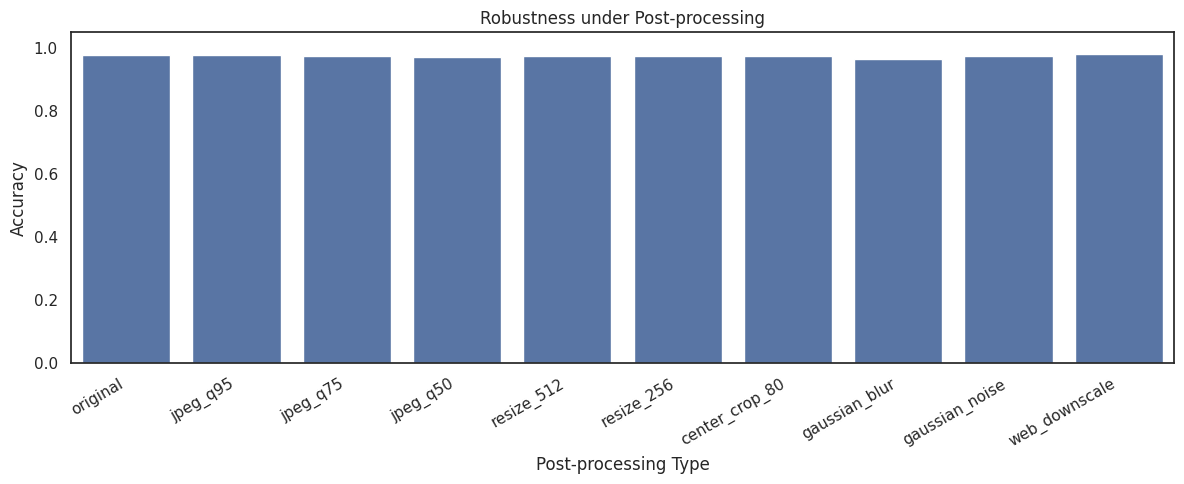

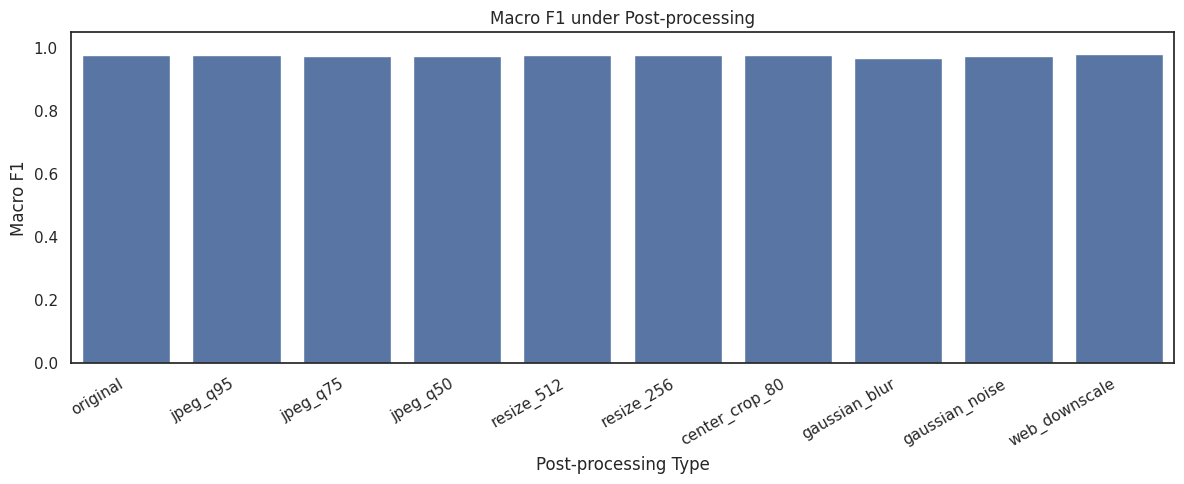

In [ ]:
# ============================================================
# 17-5) Robustness under Post-processing
# ============================================================

print("\n" + "#" * 80)
print("# Robustness under Post-processing")
print("#" * 80)

def transform_image_pil(img, transform_name):
    """
    img: PIL RGB image
    return: transformed PIL RGB image
    """
    img = img.convert("RGB")

    if transform_name == "original":
        return img

    if transform_name == "jpeg_q95":
        return img

    if transform_name == "jpeg_q75":
        return img

    if transform_name == "jpeg_q50":
        return img

    if transform_name == "resize_512":
        return img.resize((512, 512)).resize(img.size)

    if transform_name == "resize_256":
        return img.resize((256, 256)).resize(img.size)

    if transform_name == "center_crop_80":
        w, h = img.size
        crop_ratio = 0.80
        nw, nh = int(w * crop_ratio), int(h * crop_ratio)
        left = (w - nw) // 2
        top = (h - nh) // 2
        cropped = img.crop((left, top, left + nw, top + nh))
        return cropped.resize((w, h))

    if transform_name == "gaussian_blur":
        arr = np.array(img)
        arr = cv2.GaussianBlur(arr, (5, 5), 0)
        return Image.fromarray(arr)

    if transform_name == "gaussian_noise":
        arr = np.array(img).astype(np.float32)
        # Use deterministic per-image RNG for reproducibility
        noise_rng = np.random.default_rng(SEED + hash(img.tobytes()) % (2**31))
        noise = noise_rng.normal(0, 5, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)

    if transform_name == "web_downscale":
        # Simulated web/social-media downscale
        w, h = img.size
        small = img.resize((max(128, w // 2), max(128, h // 2)))
        return small.resize((w, h))

    raise ValueError(f"Unknown transform: {transform_name}")


def save_transformed_temp(img, transform_name, tmp_dir, idx):
    """
    # JPEG quality is applied at save time.
    """
    out_path = os.path.join(tmp_dir, f"tmp_{idx}_{transform_name}.jpg")

    if transform_name == "jpeg_q95":
        img.save(out_path, quality=95)
    elif transform_name == "jpeg_q75":
        img.save(out_path, quality=75)
    elif transform_name == "jpeg_q50":
        img.save(out_path, quality=50)
    else:
        img.save(out_path, quality=95)

    return out_path


def predict_paths_with_existing_pipeline(paths, bundle_path=ARTIFACT_SAVE):
    """
    # Batch prediction returning probability vectors.
    """
    bundle = load_bundle(bundle_path)
    all_proba = []

    for p in tqdm(paths, desc="Predict transformed images"):
        x = build_single_feature_vector(p, bundle)

        proba_lr = bundle["clf_lr"].predict_proba(x)[0]
        proba_xgb = bundle["clf_xgb"].predict_proba(x)[0]
        proba = 0.5 * proba_lr + 0.5 * proba_xgb

        all_proba.append(proba)

    return np.vstack(all_proba)


def robustness_experiment(
    original_paths,
    y_true,
    transform_names,
    max_per_class=200,
    random_state=SEED
):
    rng = np.random.default_rng(random_state)

    selected_indices = []
    for cls in np.unique(y_true):
        cls_indices = np.where(y_true == cls)[0]
        if max_per_class is not None:
            cls_indices = rng.choice(
                cls_indices,
                size=min(max_per_class, len(cls_indices)),
                replace=False
            )
        selected_indices.extend(cls_indices.tolist())

    selected_indices = np.array(selected_indices)
    selected_paths = [original_paths[i] for i in selected_indices]
    selected_y = y_true[selected_indices]

    rows = []

    with tempfile.TemporaryDirectory() as tmp_dir:
        for tname in transform_names:
            print(f"\n[ROBUSTNESS] Transform = {tname}")

            transformed_paths = []

            for i, p in enumerate(tqdm(selected_paths, desc=f"Creating {tname}")):
                img = Image.open(p).convert("RGB")
                img_t = transform_image_pil(img, tname)
                tmp_path = save_transformed_temp(img_t, tname, tmp_dir, i)
                transformed_paths.append(tmp_path)

            proba_t = predict_paths_with_existing_pipeline(transformed_paths, ARTIFACT_SAVE)
            y_pred_t = np.argmax(proba_t, axis=1)

            acc = accuracy_score(selected_y, y_pred_t)
            macro_f1 = f1_score(selected_y, y_pred_t, average="macro", zero_division=0)
            mean_conf = float(np.mean(np.max(proba_t, axis=1)))

            rows.append({
                "Transform": tname,
                "Accuracy": acc,
                "Macro F1": macro_f1,
                "Mean Confidence": mean_conf,
                "N": len(selected_y)
            })

            print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f} | Mean Confidence: {mean_conf:.4f}")

    return pd.DataFrame(rows)


# test_idx from train/val/test split
test_paths = [image_paths[i] for i in test_idx]

transform_names = [
    "original",
    "jpeg_q95",
    "jpeg_q75",
    "jpeg_q50",
    "resize_512",
    "resize_256",
    "center_crop_80",
    "gaussian_blur",
    "gaussian_noise",
    "web_downscale",
]

robustness_df = robustness_experiment(
    original_paths=test_paths,
    y_true=y_test,
    transform_names=transform_names,
    max_per_class=None,
    random_state=SEED
)

print("\n[ROBUSTNESS TABLE]")
display(robustness_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=robustness_df, x="Transform", y="Accuracy")
plt.title("Robustness under Post-processing")
plt.ylabel("Accuracy")
plt.xlabel("Post-processing Type")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=robustness_df, x="Transform", y="Macro F1")
plt.title("Macro F1 under Post-processing")
plt.ylabel("Macro F1")
plt.xlabel("Post-processing Type")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 17-6) Save additional experiment results
# ============================================================

os.makedirs(ADDITIONAL_RESULT_DIR, exist_ok=True)

ablation_df.to_csv(os.path.join(ADDITIONAL_RESULT_DIR, "ablation_results.csv"), index=False)
threshold_df.to_csv(os.path.join(ADDITIONAL_RESULT_DIR, "confidence_threshold_sweep.csv"), index=False)
robustness_df.to_csv(os.path.join(ADDITIONAL_RESULT_DIR, "postprocessing_robustness.csv"), index=False)

print(f"[SAVED] Additional experiment results -> {ADDITIONAL_RESULT_DIR}")

[SAVED] Additional experiment results -> /content/drive/MyDrive/Window_AIGIAttributor&novelty


In [ ]:
# ============================================================
# 18) Open-Set: Leave-One-Generator-Out + Enhanced OOD Detection
#     (Mahalanobis Distance + Energy Score + Hybrid)
# ============================================================

os.makedirs(ADDITIONAL_RESULT_DIR, exist_ok=True)

# Load raw features
raw = joblib.load(RAW_FEATURES_PATH)
X_art_all  = raw["X_art"]
X_dino_all = raw["X_dino"]
X_clip_all = raw["X_clip"]
all_labels = np.array(raw["labels"])
all_paths  = raw["image_paths"]

generators = sorted(list(set(all_labels)))
print(f"All generators: {generators}")


# ============================================================
# OOD Scoring Functions
# ============================================================

class MahalanobisOODScorer:
    #Per-class Mahalanobis distance with Ledoit-Wolf covariance estimation.
    def __init__(self):
        self.class_means = {}
        self.precision_matrix = None

    def fit(self, X_train, y_train):
        classes = np.unique(y_train)
        for c in classes:
            self.class_means[c] = np.mean(X_train[y_train == c], axis=0)

        # Shared covariance from class-centered residuals
        residuals = np.zeros_like(X_train)
        for i, yi in enumerate(y_train):
            residuals[i] = X_train[i] - self.class_means[yi]

        lw = LedoitWolf()
        lw.fit(residuals)
        self.precision_matrix = lw.precision_
        return self

    def score(self, X):
        #Min Mahalanobis distance to any class. Higher = more OOD.
        distances = np.zeros((len(X), len(self.class_means)))
        for c, mean_c in self.class_means.items():
            diff = X - mean_c
            left = diff @ self.precision_matrix
            distances[:, c] = np.sqrt(np.maximum(np.sum(left * diff, axis=1), 0))
        return np.min(distances, axis=1)


def compute_energy_score(X, lr_model, xgb_model, temperature=1.0):
    #Energy-based OOD score. Returns negated energy; higher = more OOD.
    logits_lr = lr_model.decision_function(X)

    dmat = xgb_module.DMatrix(X)
    logits_xgb = xgb_model.get_booster().predict(dmat, output_margin=True)

    logits_avg = 0.5 * logits_lr + 0.5 * logits_xgb

    # Numerically stable logsumexp
    scaled = logits_avg / temperature
    max_scaled = np.max(scaled, axis=1, keepdims=True)
    lse = max_scaled.squeeze() + np.log(
        np.sum(np.exp(scaled - max_scaled), axis=1) + 1e-10
    )
    energy = temperature * lse  # higher = more in-distribution

    return -energy  # Negate: higher = more OOD


class HybridOODScorer:
    #Weighted combination of MSP, Mahalanobis, and Energy scores (z-normalized).

    def __init__(self, alpha_msp=0.2, alpha_maha=0.5, alpha_energy=0.3):
        self.alpha_msp = alpha_msp
        self.alpha_maha = alpha_maha
        self.alpha_energy = alpha_energy
        self.maha_scorer = MahalanobisOODScorer()

    def fit(self, X_train, y_train, lr_model, xgb_model):
        self.maha_scorer.fit(X_train, y_train)

        proba_train = 0.5 * lr_model.predict_proba(X_train) + \
                      0.5 * xgb_model.predict_proba(X_train)

        msp_tr   = 1.0 - np.max(proba_train, axis=1)
        maha_tr  = self.maha_scorer.score(X_train)
        nrg_tr   = compute_energy_score(X_train, lr_model, xgb_model)

        self.msp_mean,  self.msp_std  = np.mean(msp_tr),  np.std(msp_tr)  + 1e-8
        self.maha_mean, self.maha_std = np.mean(maha_tr), np.std(maha_tr) + 1e-8
        self.nrg_mean,  self.nrg_std  = np.mean(nrg_tr),  np.std(nrg_tr)  + 1e-8
        return self

    def score(self, X, lr_model, xgb_model):
        proba = 0.5 * lr_model.predict_proba(X) + 0.5 * xgb_model.predict_proba(X)

        msp  = (1.0 - np.max(proba, axis=1) - self.msp_mean)  / self.msp_std
        maha = (self.maha_scorer.score(X)     - self.maha_mean) / self.maha_std
        nrg  = (compute_energy_score(X, lr_model, xgb_model) - self.nrg_mean) / self.nrg_std

        hybrid = self.alpha_msp * msp + self.alpha_maha * maha + self.alpha_energy * nrg
        return hybrid, proba


# ============================================================
# LOSO Trial
# ============================================================

def run_leave_one_out_trial_enhanced(
    held_out_gen, X_art_all, X_dino_all, X_clip_all, all_labels
):
    known_mask  = all_labels != held_out_gen
    unseen_mask = all_labels == held_out_gen

    X_art_known  = X_art_all[known_mask]
    X_dino_known = X_dino_all[known_mask]
    X_clip_known = X_clip_all[known_mask]
    labels_known = all_labels[known_mask]

    X_art_unseen  = X_art_all[unseen_mask]
    X_dino_unseen = X_dino_all[unseen_mask]
    X_clip_unseen = X_clip_all[unseen_mask]

    le_trial = LabelEncoder()
    y_known = le_trial.fit_transform(labels_known)
    num_classes = len(le_trial.classes_)

    indices = np.arange(len(y_known))
    train_idx, val_idx = train_test_split(
        indices, test_size=0.2, random_state=SEED, stratify=y_known
    )

    # --- Scale & PCA ---
    art_scaler = StandardScaler()
    X_art_tr = art_scaler.fit_transform(X_art_known[train_idx])
    X_art_vl = art_scaler.transform(X_art_known[val_idx])
    X_art_un = art_scaler.transform(X_art_unseen)

    dino_scaler = StandardScaler()
    X_dino_tr_s = dino_scaler.fit_transform(X_dino_known[train_idx])
    X_dino_vl_s = dino_scaler.transform(X_dino_known[val_idx])
    X_dino_un_s = dino_scaler.transform(X_dino_unseen)

    dino_pca_dim = min(256, X_dino_tr_s.shape[0] - 1, X_dino_tr_s.shape[1])
    dino_pca = PCA(n_components=dino_pca_dim, random_state=SEED)
    X_dino_tr_p = dino_pca.fit_transform(X_dino_tr_s)
    X_dino_vl_p = dino_pca.transform(X_dino_vl_s)
    X_dino_un_p = dino_pca.transform(X_dino_un_s)

    clip_scaler = StandardScaler()
    X_clip_tr_s = clip_scaler.fit_transform(X_clip_known[train_idx])
    X_clip_vl_s = clip_scaler.transform(X_clip_known[val_idx])
    X_clip_un_s = clip_scaler.transform(X_clip_unseen)

    clip_pca_dim = min(256, X_clip_tr_s.shape[0] - 1, X_clip_tr_s.shape[1])
    clip_pca = PCA(n_components=clip_pca_dim, random_state=SEED)
    X_clip_tr_p = clip_pca.fit_transform(X_clip_tr_s)
    X_clip_vl_p = clip_pca.transform(X_clip_vl_s)
    X_clip_un_p = clip_pca.transform(X_clip_un_s)

    X_tr = np.concatenate([X_art_tr, X_dino_tr_p, X_clip_tr_p], axis=1)
    X_vl = np.concatenate([X_art_vl, X_dino_vl_p, X_clip_vl_p], axis=1)
    X_un = np.concatenate([X_art_un, X_dino_un_p, X_clip_un_p], axis=1)

    y_tr = y_known[train_idx]
    y_vl = y_known[val_idx]

    # --- Train LR + XGB ---
    lr = LogisticRegression(
        max_iter=3000, C=2.0, class_weight="balanced",
        solver="saga", multi_class="multinomial",
        n_jobs=-1, random_state=SEED
    )
    lr.fit(X_tr, y_tr)

    xgb_clf = XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.04,
        subsample=0.9, colsample_bytree=0.9,
        objective="multi:softprob", num_class=num_classes,
        reg_lambda=2.0, random_state=SEED,
        tree_method="hist", eval_metric="mlogloss",
        early_stopping_rounds=30
    )
    xgb_clf.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)

    # Known val performance
    proba_vl = 0.5 * lr.predict_proba(X_vl) + 0.5 * xgb_clf.predict_proba(X_vl)
    y_vl_pred = np.argmax(proba_vl, axis=1)
    known_acc = accuracy_score(y_vl, y_vl_pred)
    known_f1  = f1_score(y_vl, y_vl_pred, average="macro", zero_division=0)

    ## Unseen MSP scores
    proba_un = 0.5 * lr.predict_proba(X_un) + 0.5 * xgb_clf.predict_proba(X_un)
    unseen_max_conf = np.max(proba_un, axis=1)
    unseen_pred_idx = np.argmax(proba_un, axis=1)
    unseen_pred_labels = le_trial.inverse_transform(unseen_pred_idx)
    pred_dist = pd.Series(unseen_pred_labels).value_counts(normalize=True)

    # MSP reject rates
    msp_thresholds = [0.3, 0.4, 0.45, 0.5, 0.6, 0.7]
    msp_reject_rates = {th: float(np.mean(unseen_max_conf < th)) for th in msp_thresholds}

    # --- Enhanced OOD Scoring ---
    hybrid_scorer = HybridOODScorer(alpha_msp=0.2, alpha_maha=0.5, alpha_energy=0.3)
    hybrid_scorer.fit(X_tr, y_tr, lr, xgb_clf)

    # OOD scores
    ood_hybrid_un, _ = hybrid_scorer.score(X_un, lr, xgb_clf)
    ood_hybrid_vl, _ = hybrid_scorer.score(X_vl, lr, xgb_clf)

    maha_un = hybrid_scorer.maha_scorer.score(X_un)
    maha_vl = hybrid_scorer.maha_scorer.score(X_vl)

    energy_un = compute_energy_score(X_un, lr, xgb_clf)
    energy_vl = compute_energy_score(X_vl, lr, xgb_clf)

    msp_ood_un = 1.0 - unseen_max_conf
    msp_ood_vl = 1.0 - np.max(proba_vl, axis=1)

    # Percentile-based reject rates
    pct_thresholds = [90, 95, 99]
    method_reject_rates = {}

    for method_name, scores_un, scores_vl in [
        ("MSP",         msp_ood_un,    msp_ood_vl),
        ("Mahalanobis", maha_un,       maha_vl),
        ("Energy",      energy_un,     energy_vl),
        ("Hybrid",      ood_hybrid_un, ood_hybrid_vl),
    ]:
        for pct in pct_thresholds:
            th = np.percentile(scores_vl, pct)
            rej = float(np.mean(scores_un > th))
            method_reject_rates[f"{method_name}@{pct}pct"] = rej

    # --- Print ---
    print(f"\n[OPEN-SET] Held out: {held_out_gen}")
    print(f"  Known val acc: {known_acc:.4f} | Macro F1: {known_f1:.4f}")
    print(f"  Unseen mean conf: {np.mean(unseen_max_conf):.4f} | "
          f"median: {np.median(unseen_max_conf):.4f}")
    print(f"  MSP reject rates: {msp_reject_rates}")
    print(f"  Enhanced reject rates (OOD > val-percentile):")
    for k, v in method_reject_rates.items():
        print(f"    {k}: {v:.4f}")

    return {
        "held_out": held_out_gen,
        "known_val_acc": known_acc,
        "known_val_macro_f1": known_f1,
        "unseen_mean_conf": float(np.mean(unseen_max_conf)),
        "unseen_median_conf": float(np.median(unseen_max_conf)),
        "unseen_std_conf": float(np.std(unseen_max_conf)),
        "unseen_n": int(unseen_mask.sum()),
        "msp_reject_rates": msp_reject_rates,
        "method_reject_rates": method_reject_rates,
        "pred_distribution": pred_dist.to_dict(),
        "unseen_max_conf_array": unseen_max_conf,
        "ood_hybrid_unseen": ood_hybrid_un,
        "ood_hybrid_known": ood_hybrid_vl,
        "ood_maha_unseen": maha_un,
        "ood_maha_known": maha_vl,
        "ood_energy_unseen": energy_un,
        "ood_energy_known": energy_vl,
    }

All generators: [np.str_('biggan'), np.str_('dalle3'), np.str_('firefly'), np.str_('midjourney'), np.str_('progan'), np.str_('sd2.0'), np.str_('stylegan3')]


In [ ]:
# ============================================================
# Run all trials
# ============================================================

all_results = []
for gen in generators:
    res = run_leave_one_out_trial_enhanced(
        gen, X_art_all, X_dino_all, X_clip_all, all_labels
    )
    all_results.append(res)


# ============================================================
# Summary Table
# ============================================================

summary_rows = []
for r in all_results:
    row = {
        "Held-out Generator": r["held_out"],
        "Known Val Acc": r["known_val_acc"],
        "Known Val F1": r["known_val_macro_f1"],
        "Unseen Mean Conf": r["unseen_mean_conf"],
        "N": r["unseen_n"],
    }
    for th, rate in r["msp_reject_rates"].items():
        row[f"MSP_Reject@{th}"] = rate
    for k, v in r["method_reject_rates"].items():
        row[k] = v
    summary_rows.append(row)

open_set_df = pd.DataFrame(summary_rows)
print("\n[OPEN-SET SUMMARY TABLE]")
display(open_set_df)


[OPEN-SET] Held out: biggan
  Known val acc: 0.9879 | Macro F1: 0.9884
  Unseen mean conf: 0.7831 | median: 0.8419
  MSP reject rates: {0.3: 0.0004, 0.4: 0.022, 0.45: 0.0524, 0.5: 0.1068, 0.6: 0.24, 0.7: 0.3444}
  Enhanced reject rates (OOD > val-percentile):
    MSP@90pct: 0.7892
    MSP@95pct: 0.5552
    MSP@99pct: 0.1952
    Mahalanobis@90pct: 0.6816
    Mahalanobis@95pct: 0.4140
    Mahalanobis@99pct: 0.0736
    Energy@90pct: 0.8364
    Energy@95pct: 0.7036
    Energy@99pct: 0.4264
    Hybrid@90pct: 0.8244
    Hybrid@95pct: 0.5624
    Hybrid@99pct: 0.2068

[OPEN-SET] Held out: dalle3
  Known val acc: 0.9890 | Macro F1: 0.9893
  Unseen mean conf: 0.8505 | median: 0.9279
  MSP reject rates: {0.3: 0.0, 0.4: 0.0008, 0.45: 0.002, 0.5: 0.0088, 0.6: 0.1348, 0.7: 0.2252}
  Enhanced reject rates (OOD > val-percentile):
    MSP@90pct: 0.7240
    MSP@95pct: 0.5192
    MSP@99pct: 0.1524
    Mahalanobis@90pct: 0.3448
    Mahalanobis@95pct: 0.1096
    Mahalanobis@99pct: 0.0064
    Energy@90pct:

,Held-out Generator,Known Val Acc,Known Val F1,Unseen Mean Conf,N,MSP_Reject@0.3,MSP_Reject@0.4,MSP_Reject@0.45,MSP_Reject@0.5,MSP_Reject@0.6,...,MSP@99pct,Mahalanobis@90pct,Mahalanobis@95pct,Mahalanobis@99pct,Energy@90pct,Energy@95pct,Energy@99pct,Hybrid@90pct,Hybrid@95pct,Hybrid@99pct
0,biggan,0.987909,0.988426,0.783082,2500,0.000400,0.022000,0.052400,0.106800,0.240000,...,0.195200,0.681600,0.414000,0.07360,0.836400,0.703600,0.426400,0.824400,0.562400,0.206800
1,dalle3,0.988976,0.989316,0.850526,2500,0.000000,0.000800,0.002000,0.008800,0.134800,...,0.152400,0.344800,0.109600,0.00640,0.696800,0.493600,0.210000,0.743200,0.521200,0.154400
2,firefly,0.985862,0.986168,0.793835,2058,0.000000,0.002915,0.007775,0.028183,0.252187,...,0.243926,0.331390,0.195821,0.04033,0.814869,0.622935,0.230807,0.804179,0.590379,0.245870
3,midjourney,0.997866,0.997886,0.756649,2500,0.001600,0.024000,0.048800,0.100800,0.282000,...,0.592800,0.349200,0.186800,0.01840,0.973200,0.928400,0.761600,0.953600,0.886800,0.594400
4,progan,0.990043,0.990542,0.747804,2500,0.000000,0.000400,0.001600,0.005600,0.311200,...,0.226800,0.911200,0.718800,0.00880,0.402000,0.128400,0.021200,0.853600,0.701600,0.250800
5,sd2.0,0.997511,0.997595,0.829609,2500,0.000000,0.012000,0.028800,0.070400,0.194800,...,0.425600,0.617200,0.396800,0.07760,0.866000,0.773600,0.551600,0.888400,0.776800,0.429600
6,stylegan3,0.990041,0.990255,0.623990,1999,0.012506,0.137069,0.244122,0.365683,0.522261,...,0.486743,0.031516,0.004002,0.00000,0.998499,0.981991,0.899950,0.969985,0.840920,0.484242


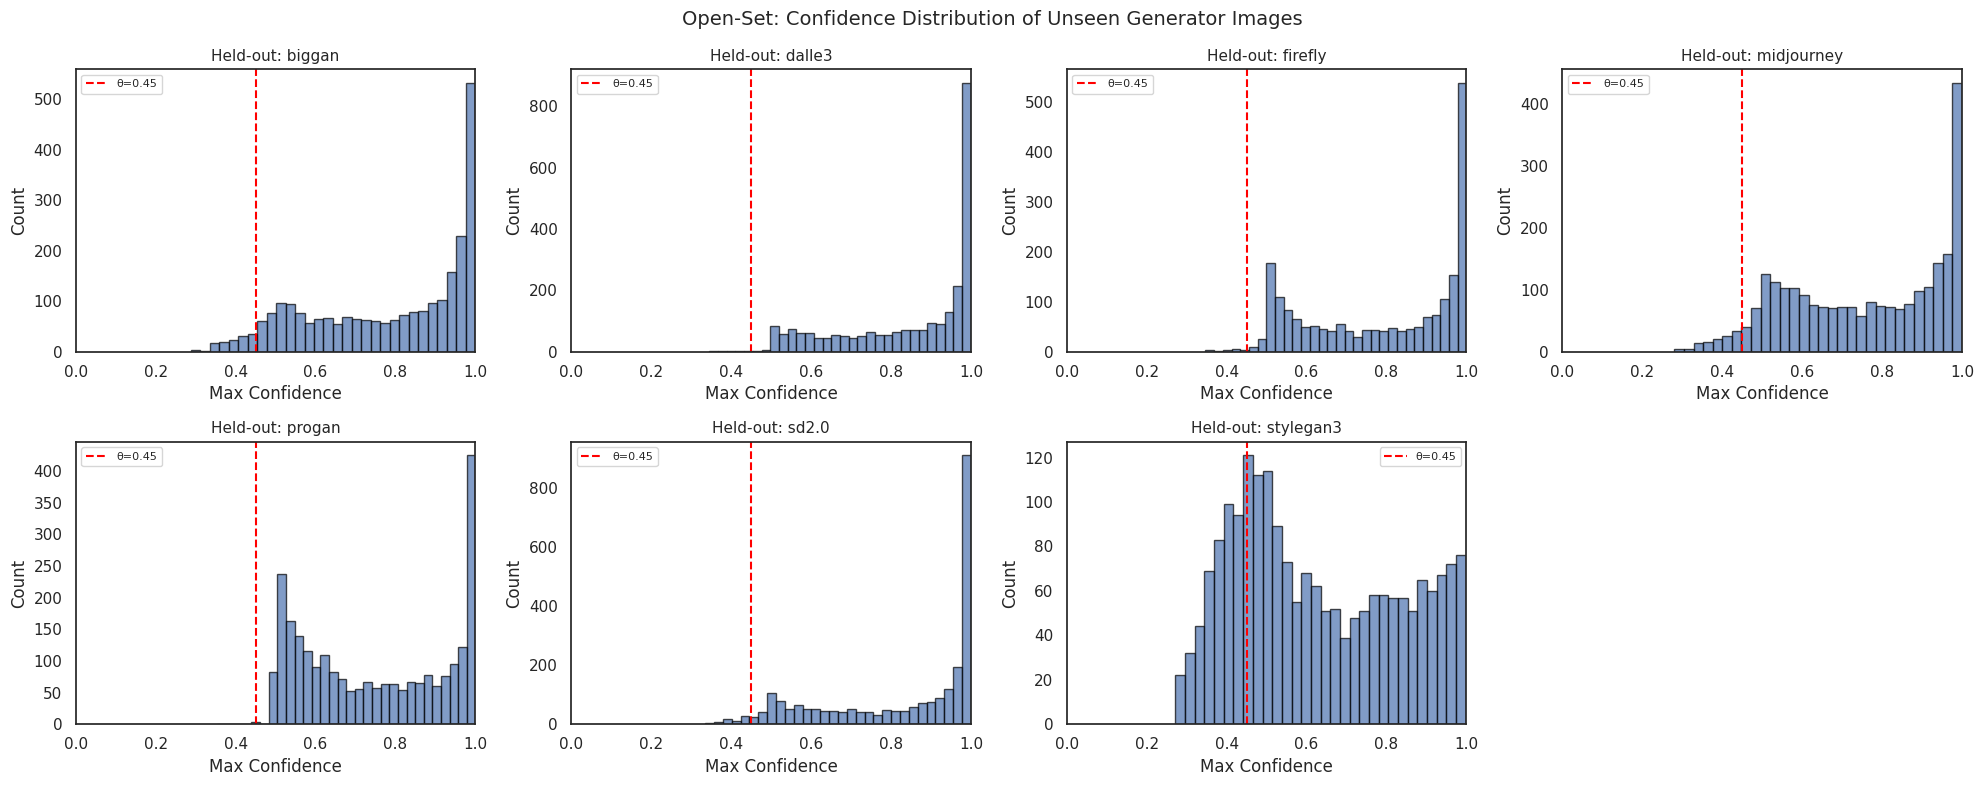

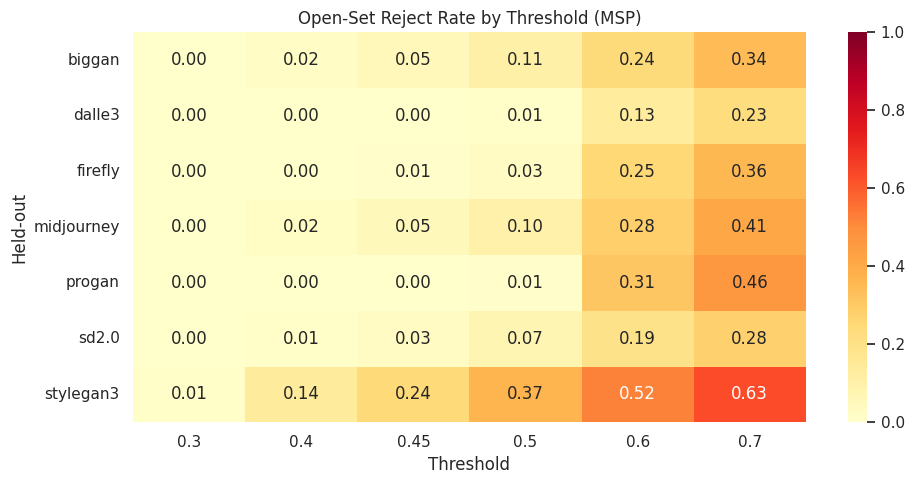

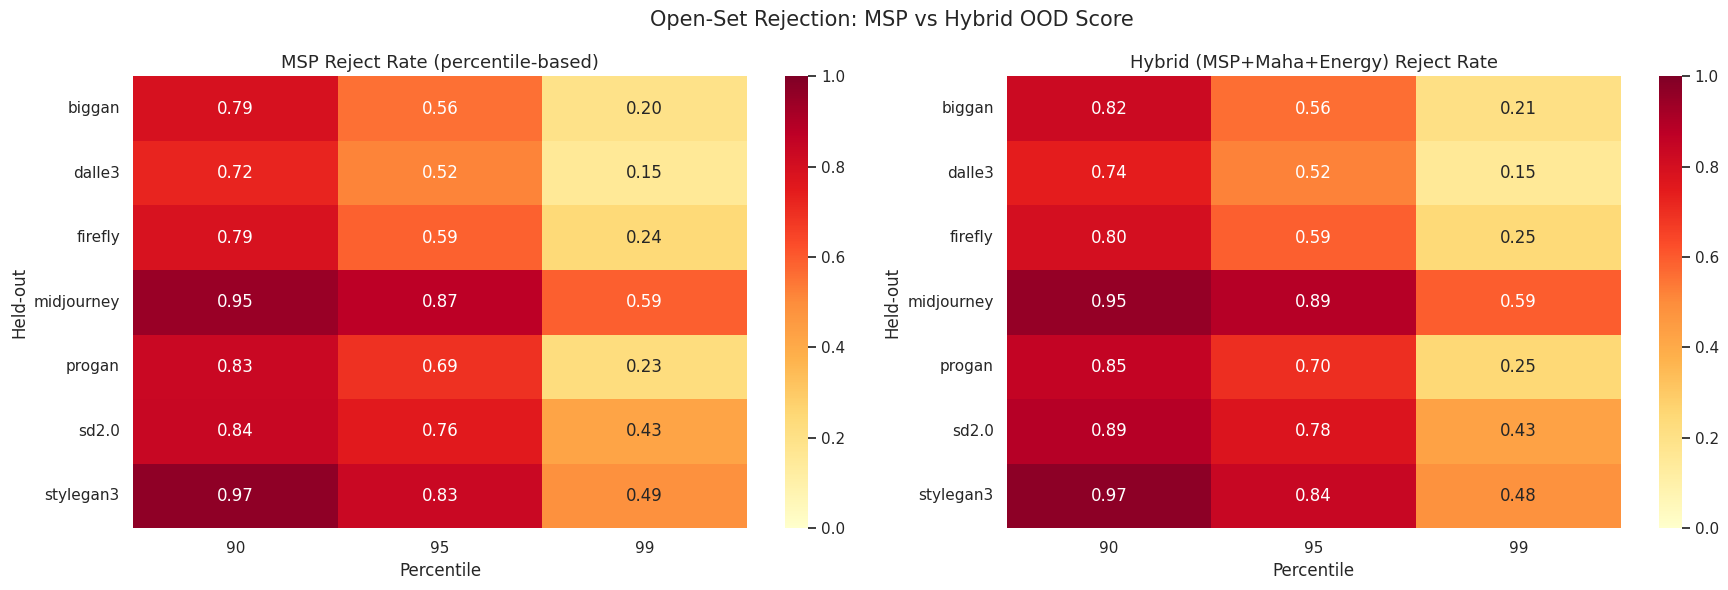

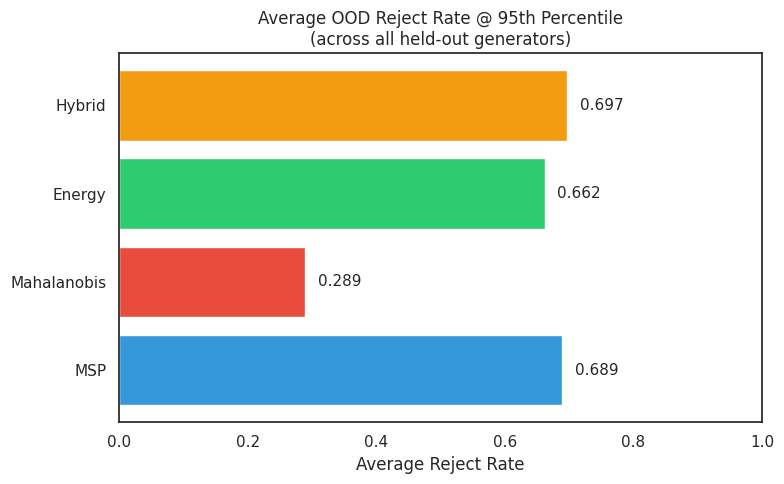

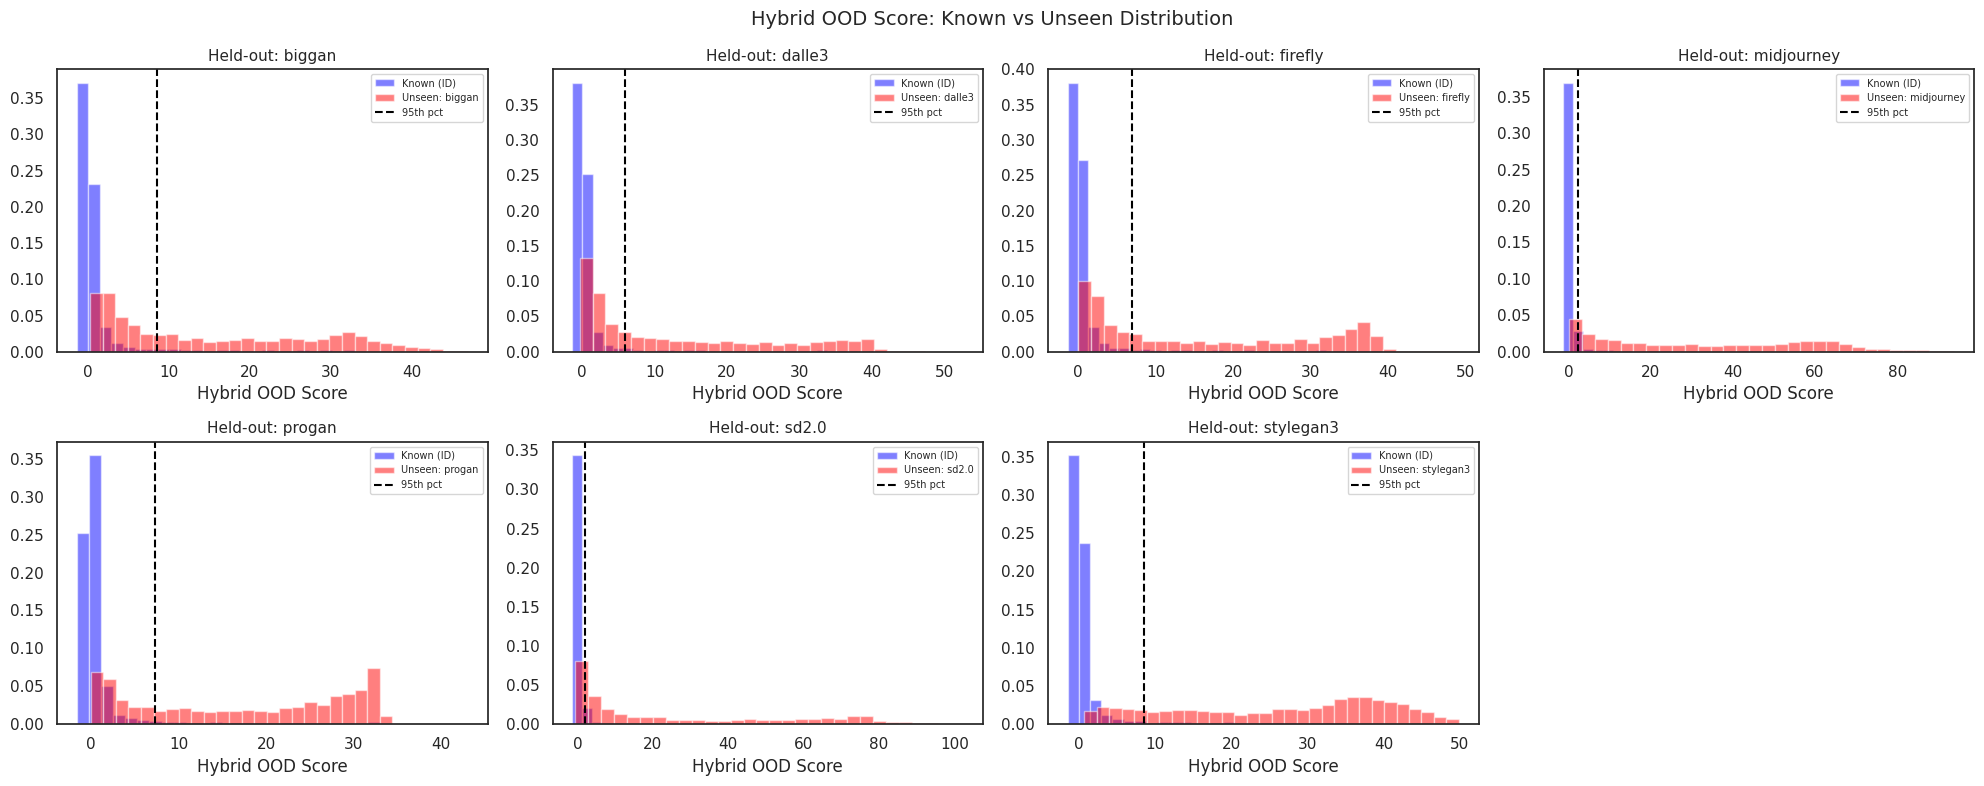

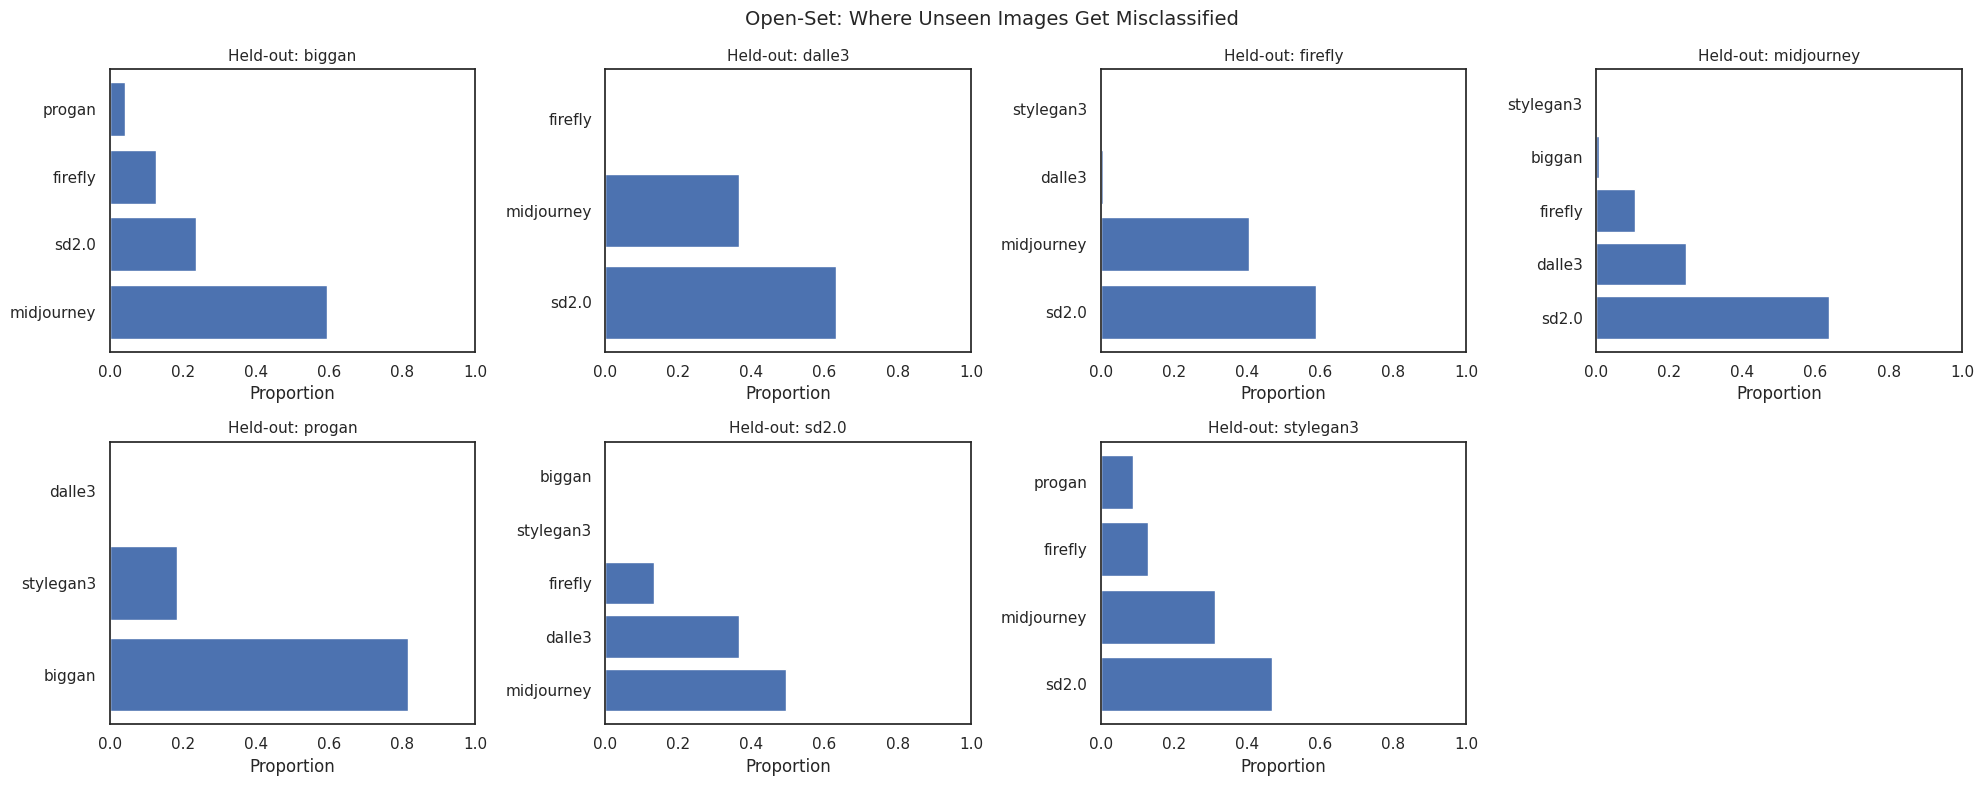

In [ ]:
# ============================================================
# Visualization 1: MSP Confidence Distribution
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, r in enumerate(all_results):
    if i >= len(axes): break
    ax = axes[i]
    ax.hist(r["unseen_max_conf_array"], bins=30, alpha=0.7, edgecolor="black")
    ax.axvline(x=0.45, color="red", linestyle="--", label="θ=0.45")
    ax.set_title(f"Held-out: {r['held_out']}", fontsize=11)
    ax.set_xlabel("Max Confidence")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
for j in range(len(all_results), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Open-Set: Confidence Distribution of Unseen Generator Images", fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# Visualization 2: MSP Reject Rate Heatmap
# ============================================================

reject_data = []
for r in all_results:
    for th, rate in r["msp_reject_rates"].items():
        reject_data.append({"Held-out": r["held_out"], "Threshold": th, "Reject Rate": rate})
reject_pivot = pd.DataFrame(reject_data).pivot(index="Held-out", columns="Threshold", values="Reject Rate")

plt.figure(figsize=(10, 5))
sns.heatmap(reject_pivot, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Open-Set Reject Rate by Threshold (MSP)")
plt.tight_layout()
plt.show()


# ============================================================
# Visualization 3: MSP vs Hybrid comparison Heatmap
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Unify to percentile-based thresholds
msp_pct_data = []
hybrid_pct_data = []
for r in all_results:
    for k, v in r["method_reject_rates"].items():
        method, pct = k.split("@")
        pct_val = int(pct.replace("pct", ""))
        entry = {"Held-out": r["held_out"], "Percentile": pct_val, "Reject Rate": v}
        if method == "MSP":
            msp_pct_data.append(entry)
        elif method == "Hybrid":
            hybrid_pct_data.append(entry)

msp_pct_pivot = pd.DataFrame(msp_pct_data).pivot(
    index="Held-out", columns="Percentile", values="Reject Rate"
)
hybrid_pct_pivot = pd.DataFrame(hybrid_pct_data).pivot(
    index="Held-out", columns="Percentile", values="Reject Rate"
)

sns.heatmap(msp_pct_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("MSP Reject Rate (percentile-based)", fontsize=13)

sns.heatmap(hybrid_pct_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Hybrid (MSP+Maha+Energy) Reject Rate", fontsize=13)

plt.suptitle("Open-Set Rejection: MSP vs Hybrid OOD Score", fontsize=15)
plt.tight_layout()
plt.show()


# ============================================================
# Visualization 4: Average reject rate comparison by method
# ============================================================

method_avg = {}
for method in ["MSP", "Mahalanobis", "Energy", "Hybrid"]:
    key = f"{method}@95pct"
    vals = [r["method_reject_rates"][key] for r in all_results]
    method_avg[method] = np.mean(vals)

plt.figure(figsize=(8, 5))
methods = list(method_avg.keys())
avgs = [method_avg[m] for m in methods]
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
plt.barh(methods, avgs, color=colors)
plt.title("Average OOD Reject Rate @ 95th Percentile\n(across all held-out generators)")
plt.xlabel("Average Reject Rate")
plt.xlim(0, 1)
for i, v in enumerate(avgs):
    plt.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=11)
plt.tight_layout()
plt.show()


# ============================================================
# Visualization 5: Hybrid OOD Score Distribution (Known vs Unseen)
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, r in enumerate(all_results):
    if i >= len(axes): break
    ax = axes[i]
    ax.hist(r["ood_hybrid_known"], bins=30, alpha=0.5, label="Known (ID)",
            density=True, color="blue")
    ax.hist(r["ood_hybrid_unseen"], bins=30, alpha=0.5,
            label=f"Unseen: {r['held_out']}", density=True, color="red")
    # 95th percentile threshold
    th95 = np.percentile(r["ood_hybrid_known"], 95)
    ax.axvline(x=th95, color="black", linestyle="--", label="95th pct")
    ax.set_title(f"Held-out: {r['held_out']}", fontsize=11)
    ax.set_xlabel("Hybrid OOD Score")
    ax.legend(fontsize=7)
for j in range(len(all_results), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Hybrid OOD Score: Known vs Unseen Distribution", fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# Visualization 6: Misclassification distribution
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, r in enumerate(all_results):
    if i >= len(axes): break
    ax = axes[i]
    dist = r["pred_distribution"]
    ax.barh(list(dist.keys()), list(dist.values()))
    ax.set_title(f"Held-out: {r['held_out']}", fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Proportion")
for j in range(len(all_results), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Open-Set: Where Unseen Images Get Misclassified", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Save
# ============================================================

open_set_df.to_csv(
    os.path.join(ADDITIONAL_RESULT_DIR, "open_set_enhanced_results.csv"),
    index=False
)
print("[SAVED] open_set_enhanced_results.csv")

[SAVED] open_set_enhanced_results.csv
